# PA_DISK organized pipeline

整理目标：本地优先读取 MaNGA DR17 SPX MAPS/LOGCUBE；若本地缺失则通过 Marvin 下载；PA_DISK 所需参数从 `Ellipse_fit` 输出和 `master_table.csv` 读取；函数按“输入 → I/O → PA 扫描 → 保存 → recast → MC”顺序排列。

In [8]:
!which python

/opt/jupyterhub2025/bin/python


In [2]:
# =========================================================
# 0. User inputs / run switches
# =========================================================
# 在这里集中修改外部输入；下面的代码会尽量从 Ellipse_fit 保存的
# CACHE_ROOT/ellipse/ellipse_<plateifu>.json 和 master_table.csv 自动读取参数。

from pathlib import Path
import os

# ---------- target ----------
galaxy_id = "8312-12702"       # MaNGA plateifu
plateifu = galaxy_id
plate, ifu = galaxy_id.split("-")

# ---------- local MaNGA / Marvin ----------
SAS_ROOT = Path(os.environ.get("SAS_BASE_DIR", "/home/huaijin/sas")).expanduser()
os.environ["SAS_BASE_DIR"] = str(SAS_ROOT)
DAPTYPE = "SPX-MILESHC-MASTARSSP"
DOWNLOAD_IF_MISSING = True      # 本地没有 MAPS/LOGCUBE 时自动用 Marvin downloadList 下载

# ---------- intermediate cache shared with Ellipse_fit ----------
CACHE_ROOT = Path(os.environ.get("TW_CACHE_ROOT", "/home/huaijin/TW_external/intermediate_cache")).expanduser()
ELLIPSE_DIR = CACHE_ROOT / "ellipse"
PA_DIR = CACHE_ROOT / "pa_disk"
PA_SCAN_DIR = PA_DIR / "scan_results"
RECAST_DIR = CACHE_ROOT / "recast"
RECAST_MC_ROOT = CACHE_ROOT / "recast_mc"
MASTER_CSV = CACHE_ROOT / "master_table.csv"

for _d in [CACHE_ROOT, ELLIPSE_DIR, PA_DIR, PA_SCAN_DIR, RECAST_DIR, RECAST_MC_ROOT]:
    _d.mkdir(parents=True, exist_ok=True)

# ---------- PA scan switches ----------
RUN_QUICK_VSYS_TEST = True
RUN_PA_SCAN = True
RUN_HA_SCAN = True
USE_PARALLEL = True             # 是否平行扫描；如果 joblib 不可用，函数会自动回退串行
N_JOBS = -1                     # 预留；当前 Scan_PA_parameter_grid 使用内部 parallel=True/False

# ---------- PA scan numerical settings ----------
PIXEL_SCALE = 0.5               # MaNGA reconstructed spaxel scale: arcsec/pix
V_EXTREME = 300
ROUND_BIN_DEG = 1.0
HIST_ROUND_BIN_DEG = 0.2

# ---------- MC settings ----------
RUN_PA_MC = True
N_MC = 100
MC_SEED = 20260424
MC_USE_CENTER = "circ_median"   # "circ_median" or "mode"
BUILD_MC_RECAST = True

print("galaxy_id =", galaxy_id)
print("SAS_ROOT  =", SAS_ROOT)
print("CACHE_ROOT=", CACHE_ROOT)
print("MASTER_CSV=", MASTER_CSV)


galaxy_id = 8312-12702
SAS_ROOT  = /home/huaijin/sas
CACHE_ROOT= /home/huaijin/TW_external/intermediate_cache
MASTER_CSV= /home/huaijin/TW_external/intermediate_cache/master_table.csv


## 1. Core PA-fitting / scan / save functions

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import circstd
from scipy.ndimage import label, generic_filter
from collections import Counter
from pafit.fit_kinematic_pa import fit_kinematic_pa
import pandas as pd
from scipy.ndimage import map_coordinates
try:
    from joblib import Parallel, delayed
    HAS_JOBLIB = True
except Exception:
    HAS_JOBLIB = False

from pathlib import Path
import json
import gzip
import pickle

from datetime import datetime

CACHE_ROOT = Path(os.environ.get("TW_CACHE_ROOT", "/home/huaijin/TW_external/intermediate_cache")).expanduser()
ELLIPSE_DIR = CACHE_ROOT / "ellipse"
PA_DIR = CACHE_ROOT / "pa_disk"
PA_SCAN_DIR = PA_DIR / "scan_results"
RECAST_DIR = CACHE_ROOT / "recast"
MASTER_CSV = CACHE_ROOT / "master_table.csv"

PA_DIR.mkdir(parents=True, exist_ok=True)
PA_SCAN_DIR.mkdir(parents=True, exist_ok=True)
RECAST_DIR.mkdir(parents=True, exist_ok=True)


def Build_xy_arcsec_with_center(shape, x0_pix, y0_pix, pixscale_arcsec=0.5):
    """
    根据真实星系中心 (x0_pix, y0_pix) 构建以该中心为原点的二维坐标网格。

    参数
    ----
    shape : 2D 数据形状 (ny, nx)
    x0_pix, y0_pix : 真实中心在像素坐标中的位置（可为非整数）
    pixscale_arcsec : 每像素角尺度，MaNGA 重建图通常为 0.5 arcsec/pix

    返回
    ----
    x_arcsec, y_arcsec : 以真实中心为原点的二维坐标网格，单位 arcsec
    extent_arcsec      : imshow 可直接使用的 extent，单位 arcsec
    center_index       : 最接近真实中心的整数像素索引 (cy, cx)
    """
    ny, nx = shape

    # 生成原始像素索引网格
    yy, xx = np.mgrid[:ny, :nx]

    # 把像素坐标转换成“以真实中心为原点”的 arcsec 坐标
    x_arcsec = (xx - x0_pix) * pixscale_arcsec
    y_arcsec = (yy - y0_pix) * pixscale_arcsec

    # 与 imshow(origin='lower') 配套的显示边界
    extent_arcsec = [
        -x0_pix * pixscale_arcsec,
        ((nx - 1) - x0_pix) * pixscale_arcsec,
        -y0_pix * pixscale_arcsec,
        ((ny - 1) - y0_pix) * pixscale_arcsec,
    ]

    # 找到距离 (0,0) 最近的实际像素，用于 island 标记时的“中心像素”
    cx = int(np.argmin(np.abs(x_arcsec[0, :])))
    cy = int(np.argmin(np.abs(y_arcsec[:, 0])))

    return x_arcsec.astype(float), y_arcsec.astype(float), extent_arcsec, (cy, cx)

# ========================================================
#                    Save And Load
# ========================================================
def load_ellipse_result(plateifu, outdir=ELLIPSE_DIR):
    infile = Path(outdir) / f"ellipse_{plateifu}.json"
    with open(infile, "r", encoding="utf-8") as f:
        payload = json.load(f)
    return payload

def upsert_master_row(master_csv, row_dict, key="plateifu"):
    master_csv = Path(master_csv)

    if master_csv.exists():            #Exist
        df = pd.read_csv(master_csv)
    else:
        df = pd.DataFrame()            #Or create

    row_df = pd.DataFrame([row_dict])  # Make dictionary

    if df.empty:
        df = row_df.copy()
    else:
        if key not in df.columns:      
            df[key] = None

        row_key = row_dict[key]
        mask = df[key].astype(str) == str(row_key)  #Find same key in csv

        for col in row_df.columns:
            if col not in df.columns:    # New line added / Old line updated
                df[col] = pd.NA
        for col in df.columns:           
            if col not in row_df.columns:
                row_df[col] = pd.NA

        row_df = row_df[df.columns]

        if mask.any():
            idx = df.index[mask][0]
            for col, val in row_dict.items():
                df.loc[idx, col] = val
        else:
            df = pd.concat([df, row_df], ignore_index=True)

    df.to_csv(master_csv, index=False)
    print(f"Updated master table: {master_csv}")
    return df


def save_pa_disk_summary(
    plateifu,
    summary_star,
    best_star,
    ellipse_payload,
    pa_scan_cache_file,
    outdir=PA_DIR,
):
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    a_average = float(ellipse_payload["a_average_arcsec"])
    
    PA_bar = float(ellipse_payload["PA_bar_deg_0_180"])-90
    print('PAbar',PA_bar)
    PA_disk_kin = float(summary_star["PA_mode"])

    phi_bar_disk = angle_diff_deg(PA_bar, PA_disk_kin)
    bar_half_width = a_average * abs(np.sin(np.deg2rad(phi_bar_disk)))
    print(bar_half_width)

    payload = {
        "plateifu": str(plateifu),

        "PA_disk_kin_mode_deg_0_180": PA_disk_kin,
        "PA_disk_kin_cmed_deg_0_180": float(summary_star["PA_circ_median"]),
        "PA_disk_kin_std_deg": float(summary_star["PA_std"]),
        "n_success": int(summary_star["n_success"]),

        "best_PA_err_deg": float(best_star["PA_err"]),
        "best_n_good": int(best_star.get("n_good", -1)),

        "PA_bar_deg_0_180": PA_bar,
        "a_average_arcsec": a_average,
        "phi_bar_disk_deg": phi_bar_disk,
        "bar_half_width_arcsec": float(bar_half_width),

        "pa_scan_cache_file": str(pa_scan_cache_file),
        "updated_at": datetime.now().isoformat(timespec="seconds"),
    }

    outfile = outdir / f"pa_disk_summary_{plateifu}.json"
    with open(outfile, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

    print(f"Saved PA summary: {outfile}")
    return payload, outfile
# =========================================================
# 0. 角度与坐标基础工具
# =========================================================

def angle_wrapto_180(pa):
    return np.mod(pa, 180.0)

def angle_diff_deg(a, b):
    """
    计算两个 180 度对称角之间的最小夹角差，范围 [0, 90]。
    """
    d = np.abs((np.asarray(a) - np.asarray(b)) % 180.0)
    return np.minimum(d, 180.0 - d)

def angle_from_circle(angles_deg):
    """
    对 180 度对称角做“圆统计”意义下的中位代表值。
    做法：先把角度乘2映射到普通圆周，再求平均方向，再除2映回。
    """
    ang = np.radians(np.asarray(angles_deg, dtype=float) * 2.0)
    s = np.nanmean(np.sin(ang))
    c = np.nanmean(np.cos(ang))
    out = 0.5 * np.degrees(np.arctan2(s, c))
    return angle_wrapto_180(out)


def drawhelp_pa_line(pa_deg, length_arcsec):
    """
    根据外部 PA，返回一条穿过原点、总长度为 2*length_arcsec 的直线端点。
    这在诊断图中画 PA 线时使用。

    返回:
        x_line = [x1, x2]
        y_line = [y1, y2]
    """
    theta = np.radians(pa_deg)
    dx = length_arcsec * np.cos(theta)
    dy = length_arcsec * np.sin(theta)
    return np.array([-dx, dx]), np.array([-dy, dy])



# =========================================================
# 1. Clean + Smooth + Ellipse residual mask + island
# =========================================================

def robust_velocity_clean(v_input, v_extreme=300, external_mask=None):
    """
    对速度场做基础清洗：
    1) 应用外部 mask
    2) 去掉绝对值超过 v_extreme 的极端值
    3) 减去全图中位数，尽量去除整体零点偏移
    """
    v0 = np.array(v_input, dtype=np.float64).copy()

    if external_mask is not None:
        v0[external_mask] = np.nan

    v0[np.abs(v0) > v_extreme] = np.nan

    med = np.nanmedian(v0)
    if np.isfinite(med):
        v0 = v0 - med
    # print('V_medain(or systemic V)',med)
    return v0


def valuehelp_elliptical_radius(x_arcsec, y_arcsec, pa_deg, ellipticity):
    """
    Obtain Ellipse radius from PA and e, unit= arcsec。
    pa_deg : PA
    """
    q = max(1e-3, 1.0 - ellipticity)

    # 把外部 PA 转为内部数学角
    theta = np.radians(pa_deg)
    # 将点旋转到椭圆主轴坐标系
    x_rot = x_arcsec * np.cos(theta) + y_arcsec * np.sin(theta)
    y_rot = -x_arcsec * np.sin(theta) + y_arcsec * np.cos(theta)

    # 椭圆半径（半长轴尺度）
    r_ell = np.sqrt(x_rot**2 + (y_rot / q)**2)
    return r_ell

def smooth_vmap(data, size):
    # 对含 NaN 的数组做 nanmedian 滤波。
    return generic_filter(data,function=lambda x: np.nanmedian(x),size=size,mode='nearest')


def velocity_smooth_island_precompute(
    v0,
    Rsmooth_arcsec,fvmax, center_index,
    pixscale_arcsec=0.5,):
    """
    对给定速度图做一次预计算：
    1) 中值平滑
    2) residual 与 bad mask
    3) 寻找与中心像素连通的 mainland

    这里输入的 center_index 已经是根据真实中心得到的最近像素索引，
    因此不再保留 center=None 和几何中心 fallback 的旧逻辑。
    """
    cy, cx = center_index

    # Turn smooth radius from（arcsec）to (pixel)，and get smooth window size
    Rsmooth_pix = Rsmooth_arcsec / pixscale_arcsec
    size = int(2 * Rsmooth_pix + 1)
    size = max(3, size)

    mask = np.isfinite(v0)
    vmap = v0.copy()
    vmap[~mask] = np.nan

    # Smooth by nanmedian 
    v_smooth = smooth_vmap(vmap, size=size)
    v_smooth[~mask] = np.nan

    # 取平滑图的最大幅值，作为 residual 的归一化尺度
    Vmax = np.nanmax(np.abs(v_smooth))
    residual = v0 - v_smooth

    # bad pixeil: residual > fvmax * Vmax 
    if np.isfinite(Vmax) and Vmax > 0:
        bad = np.abs(residual) / Vmax > fvmax
    else:
        bad = np.zeros_like(v0, dtype=bool)

    bad |= ~np.isfinite(v0)

    # Only Keep the connected domain containing the center
    valid_land = np.isfinite(v0)
    labels, nlab = label(valid_land)

    if nlab == 0:
        mainland = np.zeros_like(v0, dtype=bool)
        print("Caution: No valid mainland")
    else:
        center_label = labels[cy, cx]

        if center_label != 0:
            # 中心像素本身就在某个连通域里，则直接取这个连通域
            mainland = (labels == center_label)
        else:
            # 如果中心像素恰好落在 NaN 或断裂处，则退一步取最大的非零连通域
            print("Caution: Center pixel is not inside a valid island; using the largest island.")
            counts = np.bincount(labels.ravel())
            counts[0] = 0
            lab = np.argmax(counts)
            mainland = (labels == lab)

    return {
        "bad": bad,
        "Vmax": Vmax,
        "residual": residual,
        "v_smooth": v_smooth,
        "mainland": mainland,
    }

def mask_from_precomputed(
    v0,
    x_arcsec,
    y_arcsec,
    pa_deg,
    ellipticity,
    precomp,
    fbad=0.2,
    dr_arcsec=0.5,
    min_pix=10,
    remove_bar=False,
    bar_r_arcsec=0.0,
):
    """
    Given PA / ellipticity ,from [bad-pixel fraction] radial profile,
    Find an optimal elliptical truncation radius r_cut, return as mask。
    Unit for x/y is arcsec, also for r_ell 与 dr_arcsec
    """
    bad = precomp["bad"]
    mainland = precomp["mainland"]

    r_ell = valuehelp_elliptical_radius(
        x_arcsec, y_arcsec, pa_deg, ellipticity
    )

    masked_total = bad | (~mainland)

    r_max = np.nanmax(r_ell)
    r_vals = np.arange(r_max, dr_arcsec, -dr_arcsec)

    best_r = None
    best_diff = np.inf

    frac_profile = []
    r_mid_list = []

    for r_out in r_vals:
        r_in = r_out - dr_arcsec

        annulus = (r_ell >= r_in) & (r_ell < r_out)

        total = np.sum(annulus)
        if total < min_pix:
            continue

        frac_bad = np.sum(masked_total & annulus) / total
        r_mid = 0.5 * (r_in + r_out)

        frac_profile.append(frac_bad)
        r_mid_list.append(r_mid)

        diff = np.abs(frac_bad - fbad)
        if diff < best_diff:
            best_diff = diff
            best_r = r_out

    r_cut = best_r
    ell_mask = r_ell < r_cut if best_r is not None else np.zeros_like(v0, dtype=bool)

    # 如果你希望把 bar 区域剔掉，则要求 bar_r_arcsec 也用 arcsec 传入
    if remove_bar and bar_r_arcsec > 0:
        ell_mask &= (r_ell >= bar_r_arcsec)
        
    return {
        "ellipse_mask": ell_mask,
        "r_cut": r_cut,
        "r_ell": r_ell,
        "r_mid_profile": np.array(r_mid_list),
        "frac_profile": np.array(frac_profile),
    }


# =========================================================
# 3. PaFit
# =========================================================

def fit_pa_once(v_map, x_arcsec, y_arcsec, plot=False):
    """
    After mask → PaFit
    """
    mask = np.isfinite(v_map)

    angBest, angErr, vSyst = fit_kinematic_pa(
        x_arcsec[mask],
        y_arcsec[mask],
        v_map[mask],
        plot=plot,
        quiet=True,
        nsteps=180*5+1
    )

    return angBest, angErr, vSyst


# =========================================================
# 4. 单组参数迭代
# =========================================================
def iterate_PA_parameter(
    v_input,
    pa0_deg,
    ellipticity,
    x_arcsec,y_arcsec,
    center_index,
    v_extreme=300,
    Rsmooth_arcsec=3.0,
    dr_arcsec=0.5,
    fvmax=0.5,
    fbad=0.2,
    min_pix=10,
    max_iter=5,
    tol_deg=1.0,
    remove_bar=False,
    bar_r_arcsec=0.0,
    plot=False,
    precomputed=None,
    pixscale_arcsec=0.5,
):
    """
    单组参数下迭代求 kinematic PA。
    - 要求传入 x_arcsec, y_arcsec, center_index
    - 单位统一为 arcsec
    """
    # 先做速度图的基础清洗
    v0 = robust_velocity_clean(v_input, v_extreme=v_extreme)

    # 如果没有现成预计算结果，则根据真实中心做一次 precompute
    if precomputed is None:
        precomputed = velocity_smooth_island_precompute(
            v0=v0,
            Rsmooth_arcsec=Rsmooth_arcsec,
            fvmax=fvmax,
            center_index=center_index,
            pixscale_arcsec=pixscale_arcsec,
        )

    bad = precomputed["bad"]
    Vmax = precomputed["Vmax"]
    residual = precomputed["residual"]
    v_smooth = precomputed["v_smooth"]
    mainland = precomputed["mainland"]

    # 迭代初值
    pa_current = angle_wrapto_180(pa0_deg)
#    print(f'Initial PA=',{pa_current},'˚')
    history = []

    ell_mask = np.isfinite(v0)
    r_cut = np.nan
    r_ell = np.full_like(v0, np.nan, dtype=float)
    r_mid_list = np.array([])
    frac_profile = np.array([])

    contiguous_map = v0.copy()
    contiguous_map[~mainland] = np.nan

    masked_total = bad | (~mainland)

    v_masked_fvmax = v0.copy()
    v_masked_fvmax[bad] = np.nan

    final_map = None
    vsys_fit = np.nan
    pa_err = np.nan

    for i in range(max_iter):
    # 构造椭圆边界，依据当前 PA 
        ell = mask_from_precomputed(
            v0=v0,
            x_arcsec=x_arcsec,
            y_arcsec=y_arcsec,
            pa_deg=pa_current,
            ellipticity=ellipticity,
            precomp=precomputed,
            fbad=fbad,
            dr_arcsec=dr_arcsec,
            min_pix=min_pix,
            remove_bar=remove_bar,
            bar_r_arcsec=bar_r_arcsec,
        )

        ell_mask = ell["ellipse_mask"]
        r_cut = ell["r_cut"]
        r_ell = ell["r_ell"]
        r_mid_list = ell["r_mid_profile"]
        frac_profile = ell["frac_profile"]

        # 先去掉 bad / non-main island
        v_work = v0.copy()
        v_work[masked_total] = np.nan

        # 再截成椭圆区域
        final_map = v_work.copy()
        final_map[~ell_mask] = np.nan

        # plt.imshow(final_map,origin="lower",cmap="jet",vmin=-200,vmax=200,extent=extent_arcsec,)   # 用于测试计算前的cut是否正常
        # plt.show()

#       使用PaFit
        pa_newfit, pa_err, vsys_fit = fit_pa_once(
            final_map, x_arcsec, y_arcsec, plot=plot,
        )
        pa_new=angle_wrapto_180(pa_newfit-90) #Check plot=Ture diagram in PaFit
    #    print(f'PA_fit:',{pa_new})
        history.append({
            "iter": i,
            "PA_in": pa_current,
            "PA_out": pa_new,
            "PA_err": pa_err,
            "n_good": int(np.sum(np.isfinite(final_map))),
        })

        # 判断是否收敛
        dpa = angle_diff_deg(pa_new, pa_current)
        pa_current = pa_new
        if dpa < tol_deg:
            break
    # print('vsys_fit=',vsys_fit)
    # 用最终收敛的 PA，再算一次与 PA_final 完全一致的 ellipse mask
    ell_final = mask_from_precomputed(
        v0=v0,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        pa_deg=pa_current,
        ellipticity=ellipticity,
        precomp=precomputed,
        fbad=fbad,
        dr_arcsec=dr_arcsec,
        min_pix=min_pix,
        remove_bar=remove_bar,
        bar_r_arcsec=bar_r_arcsec,
    )

    ellipse_mask_final = ell_final["ellipse_mask"]
    r_cut_final = ell_final["r_cut"]
    r_ell_final = ell_final["r_ell"]
    r_mid_final = ell_final["r_mid_profile"]
    frac_final = ell_final["frac_profile"]

    # 最终真正用于 PA_final 的有效区域
    fit_valid_mask_final = (~masked_total) & ellipse_mask_final

    final_map_pa_final = v0.copy()
    final_map_pa_final[~fit_valid_mask_final] = np.nan

    return {
        "success": True,
        "PA_final": pa_current,
        "PA_err": pa_err,
        "vsys_fit": vsys_fit,
        "Vmax": Vmax,
        "n_good": history[-1]["n_good"] if history else 0,
        "history": history,

        "v_original": v0,
        "v_smooth": v_smooth,
        "residual": residual,
        "v_masked_fvmax": v_masked_fvmax,
        "v_contiguous": contiguous_map,

        # 与最终 PA_final 严格一致的结果
        "v_ellipse": final_map_pa_final,
        "ellipse_mask": ellipse_mask_final,
        "fit_valid_mask_final": fit_valid_mask_final,
        "r_cut": r_cut_final,
        "r_ell": r_ell_final,
        "r_mid_profile": r_mid_final,
        "frac_profile": frac_final,

        "bad_mask": bad,
        "mainland_mask": mainland,
        "center_index": center_index,
    }


# =========================================================
# 5. 参数扫描
# =========================================================

def _single_scan_job(
    v0,
    x_arcsec,y_arcsec,
    center_index,
    pa0_deg,
    ellipticity,
    Rs_arcsec,
    fvmax,
    fbad,
    dr_arcsec,
    min_pix,
    max_iter,
    tol_deg,
    remove_bar,
    bar_r_arcsec,
    pixscale_arcsec,
):
    """
    并行/串行扫描中的单个参数组合任务。
    """
    precomp = velocity_smooth_island_precompute(
        v0=v0,
        Rsmooth_arcsec=Rs_arcsec,
        fvmax=fvmax,
        center_index=center_index,
        pixscale_arcsec=pixscale_arcsec,
    )

    res = iterate_PA_parameter(
        v_input=v0,
        pa0_deg=pa0_deg,
        ellipticity=ellipticity,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        center_index=center_index,
        v_extreme=np.inf,   # v0 已经清洗过
        Rsmooth_arcsec=Rs_arcsec,
        dr_arcsec=dr_arcsec,
        fvmax=fvmax,
        fbad=fbad,
        min_pix=min_pix,
        max_iter=max_iter,
        tol_deg=tol_deg,
        remove_bar=remove_bar,
        bar_r_arcsec=bar_r_arcsec,
        plot=False,
        precomputed=precomp,
        pixscale_arcsec=pixscale_arcsec,
    )

    res["Rsmooth_arcsec"] = Rs_arcsec
    res["fvmax"] = fvmax
    res["fbad"] = fbad
    return res


def Scan_PA_parameter_grid(
    v_input,
    pa0_deg,
    ellipticity,
    x_arcsec,y_arcsec,
    center_index,
    v_extreme=300,
    Rsmooth_arcsec_list=(2, 3, 4, 5, 6, 7),
    fvmax_list=(0.2, 0.3, 0.4, 0.5, 0.6, 0.8),
    fbad_list=(0.2, 0.3, 0.4, 0.5),
    pixscale_arcsec=0.5,
    dr_arcsec=0.5,
    min_pix=10,
    max_iter=5,
    tol_deg=1.0,
    remove_bar=False,
    bar_r_arcsec=0.0,
    parallel=False,
    n_jobs=-1,
):
    """
    参数扫描总入口。

    输入坐标都已经是“以真实星系中心为原点、单位为 arcsec”的网格。
    """
    # 基础清洗
    v0 = robust_velocity_clean(v_input, v_extreme=v_extreme)

    jobs = []
    for Rs_arcsec in Rsmooth_arcsec_list:
        for fvmax in fvmax_list:
            for fbad in fbad_list:
                jobs.append((Rs_arcsec, fvmax, fbad))

    # 并行扫描
    if parallel:
        if not HAS_JOBLIB:
            raise ImportError("joblib 未安装，无法并行。请先 pip install joblib")

        results = Parallel(n_jobs=n_jobs, prefer="processes")(
            delayed(_single_scan_job)(
                v0=v0,
                x_arcsec=x_arcsec,
                y_arcsec=y_arcsec,
                center_index=center_index,
                pa0_deg=pa0_deg,
                ellipticity=ellipticity,
                Rs_arcsec=Rs_arcsec,
                fvmax=fvmax,
                fbad=fbad,
                dr_arcsec=dr_arcsec,
                min_pix=min_pix,
                max_iter=max_iter,
                tol_deg=tol_deg,
                remove_bar=remove_bar,
                bar_r_arcsec=bar_r_arcsec,
                pixscale_arcsec=pixscale_arcsec,
            )
            for (Rs_arcsec, fvmax, fbad) in jobs
        )
        return results

    # 串行扫描，但仍然缓存 precompute
    results = []
    precomp_cache = {}

    for Rs_arcsec in Rsmooth_arcsec_list:
        for fvmax in fvmax_list:
            key = (float(Rs_arcsec), float(fvmax))

            if key not in precomp_cache:
                precomp_cache[key] = velocity_smooth_island_precompute(
                    v0=v0,
                    Rsmooth_arcsec=Rs_arcsec,
                    fvmax=fvmax,
                    center_index=center_index,
                    pixscale_arcsec=pixscale_arcsec,
                )

            precomp = precomp_cache[key]

            for fbad in fbad_list:
                res = iterate_PA_parameter(
                    v_input=v0,
                    pa0_deg=pa0_deg,
                    ellipticity=ellipticity,
                    x_arcsec=x_arcsec,
                    y_arcsec=y_arcsec,
                    center_index=center_index,
                    v_extreme=np.inf,
                    Rsmooth_arcsec=Rs_arcsec,
                    dr_arcsec=dr_arcsec,
                    fvmax=fvmax,
                    fbad=fbad,
                    min_pix=min_pix,
                    max_iter=max_iter,
                    tol_deg=tol_deg,
                    remove_bar=remove_bar,
                    bar_r_arcsec=bar_r_arcsec,
                    plot=False,
                    precomputed=precomp,
                    pixscale_arcsec=pixscale_arcsec,
                )

                res["Rsmooth_arcsec"] = Rs_arcsec
                res["Rsmooth_pix"] = Rs_arcsec / pixscale_arcsec
                res["fvmax"] = fvmax
                res["fbad"] = fbad

                results.append(res)

    return results

# =========================================================
# 6. 结果汇总
# =========================================================

def Summarize_PA_results(results, round_bin_deg=1.0):
    """
    - mode（按 round_bin_deg 分箱）
    - circular median
    - PA scatter
    """
    pa_list = [
        r["PA_final"]
        for r in results
        if r["success"] and np.isfinite(r["PA_final"])
    ]

    pa_err_list = [
        r["PA_err"]
        for r in results
        if r["success"] and np.isfinite(r["PA_final"])
    ]

    if len(pa_list) == 0:
        return {
            "n_success": 0,
            "PA_mode": np.nan,
            "PA_circ_median": np.nan,
            "PA_std": np.nan,
            "PA_list": [],
            "PA_err_list": [],
            "round_bin_deg": round_bin_deg,
        }

    bins = [round(p / round_bin_deg) * round_bin_deg for p in pa_list]
    counts = Counter(bins)
    PA_mode = counts.most_common(1)[0][0]

    PA_cmed = angle_from_circle(pa_list)

    PA_std = circstd(pa_list, high=180, low=0)

    return {
        "n_success": len(pa_list),
        "PA_mode": angle_wrapto_180(PA_mode),
        "PA_circ_median": angle_wrapto_180(PA_cmed),
        "PA_std": PA_std,
        "PA_list": pa_list,
        "PA_err_list": pa_err_list,
        "round_bin_deg": round_bin_deg,
    }

def Pick_result_near_mode(results, summary):
    """
    Select one scan result from the PA_mode bin.

    Important:
    - summary["PA_mode"] is the mode of all successful PA_final values.
    - returned result["PA_final"] is the actual PA of one selected scan run.
    - returned result also carries summary-level fields such as PA_mode.
    """
    round_bin_deg = summary.get("round_bin_deg", 1.0)
    target_mode = angle_wrapto_180(summary["PA_mode"])

    if not np.isfinite(target_mode):
        raise ValueError("summary['PA_mode'] is not finite. No valid PA result to pick.")

    candidates = []

    for r in results:
        if not r.get("success", False):
            continue

        pa_final = r.get("PA_final", np.nan)

        if not np.isfinite(pa_final):
            continue

        pa_bin = round(pa_final / round_bin_deg) * round_bin_deg
        pa_bin = angle_wrapto_180(pa_bin)

        if angle_diff_deg(pa_bin, target_mode) < 1.0e-8:
            candidates.append(r)

    if len(candidates) == 0:
        raise ValueError(
            f"No result found in the PA_mode bin. "
            f"PA_mode={target_mode}, round_bin_deg={round_bin_deg}"
        )

    candidates = sorted(
        candidates,
        key=lambda r: (
            np.inf if not np.isfinite(r.get("PA_err", np.nan)) else r.get("PA_err", np.nan),
            -r.get("n_good", 0)
        )
    )

    best = candidates[0].copy()

    # Attach summary-level PA information to the selected result
    best["PA_mode"] = summary.get("PA_mode", np.nan)
    best["PA_circ_median"] = summary.get("PA_circ_median", np.nan)
    best["PA_std"] = summary.get("PA_std", np.nan)
    best["n_success_total"] = summary.get("n_success", 0)
    best["round_bin_deg"] = round_bin_deg

    return best

# =========================================================
# 7. 诊断图
# =========================================================
def drawhelp_pa_mode(pa_list, round_bin_deg=0.2):
    pa = np.asarray(pa_list, dtype=float)
    pa = pa[np.isfinite(pa)]

    if len(pa) == 0:
        return np.nan, Counter()

    bins = np.round(pa / round_bin_deg) * round_bin_deg
    counts = Counter(bins.tolist())
    mode_val = counts.most_common(1)[0][0]   # Most frequently PA → Mode PA
    return angle_wrapto_180(mode_val), counts

#  ↓↓↓
def plot_PA_diagnostics_six(
    result,
    extent_arcsec,
    PA_disk_phot=None,
    PA_disk_paper=None,
    vmin=-200,
    vmax=200,
    xlim=(-19, 19),
    ylim=(-19, 19),
    pa_line_key="PA_final",
):
    """
    Plot six diagnostic panels for PA fitting.

    Notes
    -----
    result["PA_final"] is the PA actually used to build result["v_ellipse"].
    result["PA_mode"] is a summary-level PA from all scan results.

    Therefore, for this diagnostic figure, the default PA line should be PA_final.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)

    data_list = [
        ("Original velocity map", result.get("v_original", None)),
        ("Smoothed map", result.get("v_smooth", None)),
        ("Residual map", result.get("residual", None)),
        ("Masked map (fvmax)", result.get("v_masked_fvmax", None)),
        ("Contiguous map", result.get("v_contiguous", None)),
        ("Ellipse-shaped velocity map", result.get("v_ellipse", None)),
    ]

    images = []

    for i, ax in enumerate(axes.ravel()):
        title, data = data_list[i]

        if data is None:
            ax.axis("off")
            images.append(None)
            continue

        im = ax.imshow(
            data,
            origin="lower",
            cmap="jet",
            vmin=vmin,
            vmax=vmax,
            extent=extent_arcsec,
        )

        ax.set_title(title)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        row = i // 3
        col = i % 3

        if row == 1:
            ax.set_xlabel("X (arcsec)", fontsize=16)
        if col == 0:
            ax.set_ylabel("Y (arcsec)", fontsize=16)

        ax.tick_params(direction="in", top=True, right=True)
        images.append(im)

        # Add PA lines only in the final ellipse panel
        if i == 5:
            L = max(abs(xlim[0]), abs(xlim[1]), abs(ylim[0]), abs(ylim[1])) * 1.2

            # Prefer PA_final, because v_ellipse was built using this PA.
            pa_plot = result.get(pa_line_key, np.nan)

            if not np.isfinite(pa_plot):
                pa_plot = result.get("PA_final", np.nan)

            if not np.isfinite(pa_plot):
                pa_plot = result.get("PA_mode", np.nan)

            if np.isfinite(pa_plot):
                xk, yk = drawhelp_pa_line(pa_plot, L)
                ax.plot(
                    xk, yk,
                    color="red",
                    lw=2,
                    label=rf"$PA_{{\rm disk,kin}}={pa_plot:.2f}^\circ$"
                )

            # Photometric PA
            if PA_disk_phot is not None and np.isfinite(PA_disk_phot):
                xp, yp = drawhelp_pa_line(PA_disk_phot, L)
                ax.plot(
                    xp, yp,
                    color="black",
                    lw=2,
                    linestyle="--",
                    label=r"$PA_{\rm disk,phot}$"
                )

            # Paper PA
            if PA_disk_paper is not None and np.isfinite(PA_disk_paper):
                xp, yp = drawhelp_pa_line(PA_disk_paper, L)
                ax.plot(
                    xp, yp,
                    color="blue",
                    lw=2,
                    linestyle="-",
                    label=r"$PA_{\rm disk,kin,paper}$"
                )

            ax.legend(loc="upper right", fontsize=9)

    # Colorbars for the rightmost panels
    for row in range(2):
        im = images[row * 3 + 2]

        if im is None:
            continue

        cbar = fig.colorbar(
            im,
            ax=axes[row, 2],
            fraction=0.045,
            pad=0.02
        )
        cbar.set_label(r"$V_{\rm los}\ ({\rm km\ s^{-1}})$")
        cbar.ax.tick_params(direction="in", right=True)
        cbar.ax.yaxis.set_ticks_position("both")

    plt.subplots_adjust(wspace=0.05, hspace=0.15)
    plt.show()

def plot_pa_histogram(
    pa_list_star,
    pa_list_ha,
    PAdisk_phot=None,
    PA_disk_paper=None,
    bins=np.arange(0, 181, 2),
    round_bin_deg=0.2
):
    pa_list_star = np.asarray(pa_list_star, dtype=float)
    pa_list_star = pa_list_star[np.isfinite(pa_list_star)]

    pa_list_ha = np.asarray(pa_list_ha, dtype=float)
    pa_list_ha = pa_list_ha[np.isfinite(pa_list_ha)]

    fig, ax = plt.subplots(figsize=(6, 4))

    # ===== histogram: probability =====
    if len(pa_list_star) > 0:
        weights_star = np.ones_like(pa_list_star) / len(pa_list_star)
        ax.hist(
            pa_list_star,
            bins=bins,
            weights=weights_star,
            histtype="bar",
            linewidth=0,
            color="hotpink",
            alpha=0.5
        )

    if len(pa_list_ha) > 0:
        weights_ha = np.ones_like(pa_list_ha) / len(pa_list_ha)
        ax.hist(
            pa_list_ha,
            bins=bins,
            weights=weights_ha,
            histtype="bar",
            linewidth=0,
            color="royalblue",
            alpha=0.5
        )

    # ===== mode lines =====
    mode_star, _ = drawhelp_pa_mode(pa_list_star, round_bin_deg=round_bin_deg)
    mode_ha, _   = drawhelp_pa_mode(pa_list_ha, round_bin_deg=round_bin_deg)
    print(mode_star)
    print(mode_ha)
    if np.isfinite(mode_star):
        ax.axvline(mode_star,ls="--",color="hotpink",lw=2)
    if np.isfinite(mode_ha):
        ax.axvline(mode_ha,ls="--",color='royalblue',lw=2)

    # ===== photometric PA =====
    if PAdisk_phot is not None and np.isfinite(PAdisk_phot):
        ax.axvline(
            angle_wrapto_180(PAdisk_phot),
            ls=":",color="black",lw=2)
    # ===== Zou paper PA =====
    if PA_disk_paper is not None and np.isfinite(PA_disk_paper):
        ax.axvline(
            angle_wrapto_180(PA_disk_paper),
            ls="--",color="black",lw=2)

    # ===== labels =====
    ax.set_xlabel(r"$PA_{\rm disk,kin}\ (^\circ)$")
    ax.set_ylabel("Probability")

    # ===== ticks: 四周、朝内、主次刻度都显示 =====
    ax.minorticks_on()
    ax.tick_params(
        axis='both',
        which='major',
        direction='in',top=True,right=True,length=6,width=1.2)
    ax.tick_params(
        axis='both',
        which='minor',
        direction='in',top=True,right=True,length=3,width=1.0)

    # ===== 右上角文字说明（不用 legend）=====
    x_text = 0.97
    y0 = 0.95
    dy = 0.08

    ax.text(
        x_text, y0, "Star",
        color="hotpink",
        transform=ax.transAxes,
        ha="right", va="top",fontsize=12)

    ax.text(
        x_text, y0 - dy,"Gas",
        color='royalblue',
        transform=ax.transAxes,
        ha="right", va="top",fontsize=12)

    ax.text(
        x_text, y0 - 2*dy, r"$PA_{\rm disk,phot}$",
        color="black",
        transform=ax.transAxes,
        ha="right", va="top", fontsize=12)
    plt.tight_layout()
    plt.show()
# =========================================================
# 8. Figure 27, f_bad:
# =========================================================
def drawhelp_collect_fbad(results, Rs_list, fvmax_list, fbad_ref=0.2):
    """
    按 (Rsmooth, fvmax) 收集 f_bad(r) 曲线。
    默认只收集固定 fbad_ref 的结果，以便和论文图保持一致。
    """
    data = {}

    for r in results:
        if (not r["success"]) or len(r["r_mid_profile"]) == 0:
            continue

        key = (r["Rsmooth_arcsec"], r["fvmax"])

        # 只保留一个固定 fbad 的系列，便于画论文式对比图
        if r["fbad"] != fbad_ref:
            continue

        data[key] = (r["r_mid_profile"], r["frac_profile"])

    return data


def plot_fbad_figure27(results_star, results_ha):
    """
    Figure 27 f_bad(r)
    """
    Rs_list = [2, 3, 4, 5, 6, 7]
    fvmax_list = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8]

    color_map = {
        0.2: "darkblue",
        0.3: "blue",
        0.4: "deepskyblue",
        0.5: "green",
        0.6: "gold",
        0.8: "red",
    }

    data_star = drawhelp_collect_fbad(results_star, Rs_list, fvmax_list, fbad_ref=0.2)
    data_ha = drawhelp_collect_fbad(results_ha, Rs_list, fvmax_list, fbad_ref=0.2)

    fig, axes = plt.subplots(2, 6, figsize=(18, 8), sharex=True, sharey=True)

    for j, Rs in enumerate(Rs_list):

        # 上排：Stars
        ax = axes[0, j]
        for fv in fvmax_list:
            key = (Rs, fv)
            if key not in data_star:
                continue

            r, f = data_star[key]
            ax.plot(r, f, color=color_map[fv], lw=2)
            ax.text(0.05, 0.92, rf"$R_{{\rm smooth}} = {Rs}''$", transform=ax.transAxes, fontsize=14)

        if j == 0:
            ax.set_ylabel(r"$f_{\rm bad}$", fontsize=14)
            ax.text(0.05, 0.85, "Stars", transform=ax.transAxes, fontsize=14)

            handles = []
            labels = []
            for fv in fvmax_list:
                handles.append(plt.Line2D([0], [0], color=color_map[fv], lw=2))
                labels.append(rf"$f_{{vmax}}={fv}$")

            ax.legend(handles, labels, frameon=False, fontsize=12, loc="lower left")

        ax.set_ylim(0, 1)
        ax.set_xlim(0, 19.8)
        ax.tick_params(direction='in', top=True, right=True, labelsize=12)

        # 下排：Gas
        ax = axes[1, j]
        for fv in fvmax_list:
            key = (Rs, fv)
            if key not in data_ha:
                continue

            r, f = data_ha[key]
            ax.plot(r, f, color=color_map[fv], lw=2)

        if j == 0:
            ax.set_ylabel(r"$f_{\rm bad}$", fontsize=14)
            ax.text(0.05, 0.85, "Gas", transform=ax.transAxes, fontsize=14)

        ax.set_xlabel("Radius (arcsec)", fontsize=14)
        ax.set_ylim(0, 0.98)
        ax.set_xlim(0, 19.8)
        ax.tick_params(direction='in', top=True, right=True, labelsize=12)

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

# =========================================================
# 8.Save and load PA_disk results
# =========================================================
import pickle
import gzip
from pathlib import Path
def save_pa_scan_results(
    results_star, results_ha,
    galaxy_id="8312-12702",
    outdir="pa_scan_cache",
    extra_meta=None):
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    filepath = outdir / f"pa_scan_results_{galaxy_id}.pkl.gz"

    payload = {
        "galaxy_id": galaxy_id,
        "results_star": results_star,
        "results_ha": results_ha,
        "meta": {} if extra_meta is None else extra_meta,
    }

    with gzip.open(filepath, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"Saved to: {filepath}")
    return str(filepath)


def load_pa_scan_results(galaxy_id="8312-12702",outdir="pa_scan_cache",):
    filepath = Path(outdir) / f"pa_scan_results_{galaxy_id}.pkl.gz"

    if not filepath.exists():
        raise FileNotFoundError(f"File not found: {filepath}")

    with gzip.open(filepath, "rb") as f:
        payload = pickle.load(f)

    results_star = payload["results_star"]
    results_ha = payload["results_ha"]

    print(f"Loaded from: {filepath}")
    return results_star, results_ha, payload


## 2. Local-first MaNGA loader and input parameter reader

In [4]:
# =========================================================
# 2. Local-first MaNGA DR17 loader + parameter reader
# =========================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS

from marvin import config
from marvin.tools import Maps
from marvin.utils.general.general import downloadList


def configure_marvin_dr17(sas_root=SAS_ROOT, daptype=DAPTYPE):
    """Configure Marvin for local/public DR17 SPX products."""
    sas_root = Path(sas_root).expanduser()
    os.environ["SAS_BASE_DIR"] = str(sas_root)
    config.mode = "local"
    config.access = "public"
    config.setRelease("DR17")
    config.daptype = daptype
    return sas_root


def expected_dap_files(galaxy_id, daptype=DAPTYPE, sas_root=SAS_ROOT):
    plate, ifu = str(galaxy_id).split("-")
    sas_root = Path(sas_root).expanduser()
    base = (sas_root / "dr17/manga/spectro/analysis/v3_1_1/3.1.0" /
            daptype / plate / ifu)
    maps_file = base / f"manga-{galaxy_id}-MAPS-{daptype}.fits.gz"
    modelcube_file = base / f"manga-{galaxy_id}-LOGCUBE-{daptype}.fits.gz"
    return maps_file, modelcube_file


def ensure_local_manga_files(galaxy_id, daptype=DAPTYPE, sas_root=SAS_ROOT, download_if_missing=True):
    """
    Local-first file resolver.
    1. Check the exact DR17 SPX MAPS and LOGCUBE paths under SAS_BASE_DIR.
    2. If missing and download_if_missing=True, call Marvin downloadList.
    3. Re-check and raise a detailed error listing available DAP products if still missing.
    """
    sas_root = configure_marvin_dr17(sas_root=sas_root, daptype=daptype)
    maps_file, modelcube_file = expected_dap_files(galaxy_id, daptype=daptype, sas_root=sas_root)

    missing = [p for p in [maps_file, modelcube_file] if not p.exists()]
    if missing and download_if_missing:
        print("[INFO] Missing local files; trying Marvin downloadList...")
        print("[INFO] Expected MAPS    :", maps_file)
        print("[INFO] Expected LOGCUBE :", modelcube_file)
        downloadList([str(galaxy_id)], dltype="maps")
        downloadList([str(galaxy_id)], dltype="modelcube")

    maps_file, modelcube_file = expected_dap_files(galaxy_id, daptype=daptype, sas_root=sas_root)
    if not maps_file.exists() or not modelcube_file.exists():
        plate, ifu = str(galaxy_id).split("-")
        analysis_root = sas_root / "dr17/manga/spectro/analysis/v3_1_1/3.1.0"
        available = sorted(analysis_root.glob(f"*/{plate}/{ifu}/manga-{galaxy_id}-*.fits.gz"))
        msg = [
            "Cannot find required DR17 SPX DAP files after local check/download.",
            f"Expected MAPS: {maps_file}",
            f"Expected LOGCUBE: {modelcube_file}",
            "Available files under analysis_root:",
        ]
        msg += [str(p) for p in available[:80]] or ["<none found>"]
        raise FileNotFoundError("\n".join(msg))

    return maps_file, modelcube_file


def load_manga_spx_maps_modelcube_dr17(
    galaxy_id=galaxy_id,
    daptype=DAPTYPE,
    sas_root=SAS_ROOT,
    download_if_missing=DOWNLOAD_IF_MISSING,
):
    """Load MaNGA DR17 SPX MAPS and matching LOGCUBE/modelcube, local-first."""
    maps_file, modelcube_file = ensure_local_manga_files(
        galaxy_id=galaxy_id,
        daptype=daptype,
        sas_root=sas_root,
        download_if_missing=download_if_missing,
    )

    maps = Maps(filename=str(maps_file))
    modelcube = maps.getModelCube()

    with fits.open(modelcube_file) as hdul:
        wave_obs = hdul["WAVE"].data.astype(float)

    return maps, modelcube, wave_obs, maps_file, modelcube_file


def load_master_row(plateifu, master_csv=MASTER_CSV):
    master_csv = Path(master_csv)
    if not master_csv.exists():
        return None
    df = pd.read_csv(master_csv)
    if "plateifu" not in df.columns:
        return None
    hit = df[df["plateifu"].astype(str) == str(plateifu)]
    if hit.empty:
        return None
    return hit.iloc[0].to_dict()


def load_pa_inputs_from_ellipse_and_master(plateifu, ellipse_dir=ELLIPSE_DIR, master_csv=MASTER_CSV):
    """
    Read PA_DISK inputs from Ellipse_fit outputs.

    Returned PA_disk_phot follows the PA_DISK internal convention used in your
    original notebook: Ellipse PA in [0,180) minus 90 deg.
    """
    ellipse_payload = load_ellipse_result(plateifu, outdir=ellipse_dir)
    master_row = load_master_row(plateifu, master_csv=master_csv)

    PA_disk_phot = float(ellipse_payload["PA_disk_phot_deg_0_180"]) - 90.0
    e_disk = float(ellipse_payload["e_disk"])

    PA_disk_paper = None
    if master_row is not None:
        for key in ["PA_disk_paper_deg_0_180", "PA_disk_paper", "PAdisk_paper", "PA_disk_literature"]:
            val = master_row.get(key, np.nan)
            if pd.notna(val):
                PA_disk_paper = float(val) - 90.0
                break

    print("[Ellipse inputs]")
    print("  PA_disk_phot internal =", PA_disk_phot, "deg  | displayed [0,180)=", PA_disk_phot + 90.0)
    print("  e_disk                =", e_disk)
    print("  PA_bar [0,180)        =", ellipse_payload.get("PA_bar_deg_0_180"))
    print("  a_average_arcsec      =", ellipse_payload.get("a_average_arcsec"))
    if PA_disk_paper is not None:
        print("  PA_disk_paper internal=", PA_disk_paper, "deg  | displayed [0,180)=", PA_disk_paper + 90.0)
    else:
        print("  PA_disk_paper         = None (not found in master table)")

    return ellipse_payload, master_row, PA_disk_phot, e_disk, PA_disk_paper


[WARNING]: cannot initiate Sentry error reporting: [Errno 25] Inappropriate ioctl for device. (UserWarning)
[INFO]: No release version set. Setting default to DR17
[WARNING]: path /home/huaijin/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/dapall-v3_1_1-3.1.0.fits cannot be found. Setting dapall to None. (MarvinUserWarning)


## 3. Load data and Ellipse_fit parameters

In [6]:
# =========================================================
# 3. Load MaNGA maps/modelcube and Ellipse_fit parameters
# =========================================================
ellipse_payload, master_row, PA_disk_phot, e_disk, PA_disk_paper = load_pa_inputs_from_ellipse_and_master(galaxy_id)

maps, modelcube, wave_obs, maps_file, modelcube_file = load_manga_spx_maps_modelcube_dr17(
    galaxy_id=galaxy_id,
    daptype=DAPTYPE,
    sas_root=SAS_ROOT,
    download_if_missing=DOWNLOAD_IF_MISSING,
)

print("Loaded MAPS    :", maps_file)
print("Loaded LOGCUBE :", modelcube_file)

# Stellar continuum surface brightness, rest-frame 5600--6750 Å.
stellar_fit = modelcube.stellarcont_fit.value.astype(float)
assert stellar_fit.shape[0] == len(wave_obs), (
    f"Spectral axis mismatch: stellar_fit.shape[0]={stellar_fit.shape[0]}, len(wave_obs)={len(wave_obs)}"
)

z = float(maps.nsa["z"])
wave_rest = wave_obs / (1.0 + z)
wave_mask = (wave_rest >= 5600.0) & (wave_rest <= 6750.0)
if np.sum(wave_mask) < 2:
    raise ValueError("Too few wavelength pixels in rest-frame 5600--6750 Å window.")
dlam = np.nanmedian(np.diff(wave_rest[wave_mask]))
stellar_surfb = np.nansum(stellar_fit[wave_mask, :, :], axis=0) * dlam

# DAP maps.
stellar_vel = maps.stellar_vel.value.astype(float)
stellar_vel[stellar_vel == 0] = np.nan
ha_flux = maps.emline_gflux_ha_6564.value.astype(float)
ha_flux[ha_flux == 0] = np.nan
ha_vel = maps.emline_gvel_ha_6564.value.astype(float)
ha_vel[ha_vel == 0] = np.nan

# Center and WCS from MAPS FITS file.
pixscale = PIXEL_SCALE
with fits.open(maps_file) as hdul:
    hdr0 = hdul[0].header
    z_header = hdr0.get("SCINPVEL", np.nan) / 299792.458 if "SCINPVEL" in hdr0 else np.nan
    ra0 = hdr0["OBJRA"]
    dec0 = hdr0["OBJDEC"]
    wcs2d = WCS(hdul["SPX_MFLUX"].header).celestial

x_pix, y_pix = wcs2d.world_to_pixel_values(ra0, dec0)
x_arcsec, y_arcsec, extent_arcsec, center_index = Build_xy_arcsec_with_center(
    shape=stellar_surfb.shape,
    x0_pix=x_pix,
    y0_pix=y_pix,
    pixscale_arcsec=pixscale,
)

print("x_pix, y_pix  =", x_pix, y_pix)
print("center_index  =", center_index)
print("extent_arcsec =", extent_arcsec)
print(ra0,dec0)

[WARNING]: path /home/huaijin/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/dapall-v3_1_1-3.1.0.fits cannot be found. Setting dapall to None. (MarvinUserWarning)


[Ellipse inputs]
  PA_disk_phot internal = 7.919549061915973 deg  | displayed [0,180)= 97.91954906191597
  e_disk                = 0.31761793758646933
  PA_bar [0,180)        = 121.39870412540995
  a_average_arcsec      = 10.11126191438994
  PA_disk_paper         = None (not found in master table)
Loaded MAPS    : /home/huaijin/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/SPX-MILESHC-MASTARSSP/8312/12702/manga-8312-12702-MAPS-SPX-MILESHC-MASTARSSP.fits.gz
Loaded LOGCUBE : /home/huaijin/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/SPX-MILESHC-MASTARSSP/8312/12702/manga-8312-12702-LOGCUBE-SPX-MILESHC-MASTARSSP.fits.gz
x_pix, y_pix  = 36.99732726359648 36.99859384098054
center_index  = (37, 37)
extent_arcsec = [-18.49866363179824, 18.00133636820176, -18.49929692049027, 18.00070307950973]
245.270870484 39.9173908047


## 4. Data diagnostic plot

[WARNING]: divide by zero encountered in log10 (RuntimeWarning)


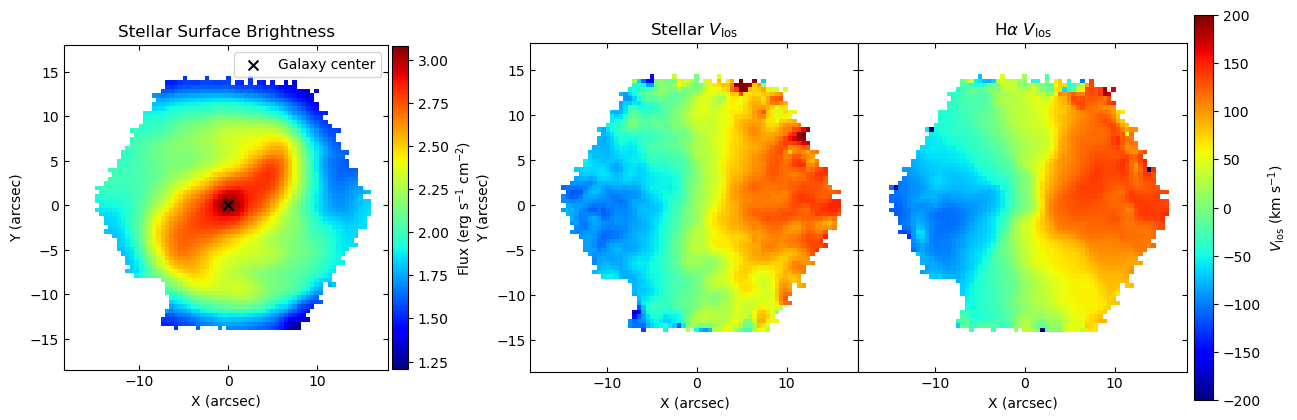

In [5]:
# =========================================================
# 4. Quick diagnostic: surface brightness and velocity maps
# =========================================================
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.9, 0.75, 0.75], wspace=0.4)
ax0 = fig.add_subplot(gs[0])
gs_right = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1:], wspace=0.0)
ax1 = fig.add_subplot(gs_right[0])
ax2 = fig.add_subplot(gs_right[1], sharey=ax1)

im0 = ax0.imshow(np.log10(stellar_surfb), origin="lower", extent=extent_arcsec, cmap="jet")
vmin, vmax = -200, 200
im1 = ax1.imshow(stellar_vel, origin="lower", extent=extent_arcsec, vmin=vmin, vmax=vmax, cmap="jet")
im2 = ax2.imshow(ha_vel, origin="lower", extent=extent_arcsec, vmin=vmin, vmax=vmax, cmap="jet")

ax0.set_title("Stellar Surface Brightness")
ax1.set_title(r"Stellar $V_{\rm los}$")
ax2.set_title(r"H$\alpha$ $V_{\rm los}$")
for ax in [ax0, ax1, ax2]:
    ax.set_xlabel("X (arcsec)")
    ax.tick_params(direction="in", top=True, right=True)
ax0.set_ylabel("Y (arcsec)")
ax1.set_ylabel("Y (arcsec)")
ax0.scatter(0, 0, marker="x", color="black", s=50, label="Galaxy center")
ax0.legend(fontsize=10)
plt.setp(ax2.get_yticklabels(), visible=False)

cbar0 = fig.colorbar(im0, ax=ax0, fraction=0.047, pad=0.01)
cbar0.set_label(r"Flux (${\rm erg\ s^{-1}\ cm^{-2}}$)")
cbar1 = fig.colorbar(im2, ax=[ax1, ax2], fraction=0.047, pad=0.01)
cbar1.set_label(r"$V_{\rm los}$ (km s$^{-1}$)")
plt.show()


## 5. Quick PA fit / Vsys reference

In [ ]:
# =========================================================
# 5. Quick PA fit to estimate Vsys reference
# =========================================================
if RUN_QUICK_VSYS_TEST:
    result_test = iterate_PA_parameter(
        v_input=stellar_vel,
        pa0_deg=PA_disk_phot,
        ellipticity=e_disk,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        center_index=center_index,
        v_extreme=500,
        Rsmooth_arcsec=3.0,
        dr_arcsec=0.5,
        fvmax=0.5,
        fbad=0.2,
        min_pix=10,
        max_iter=5,
        tol_deg=1.0,
        remove_bar=False,
        bar_r_arcsec=0.0,
        plot=False,
        pixscale_arcsec=pixscale,
    )

    print(f"PA_disk_kin, quick = {result_test['PA_final']:.2f} ± {result_test['PA_err']:.2f}")

    vmap = np.asarray(np.ma.masked_invalid(result_test["v_ellipse"]), dtype=float)
    mask = np.isfinite(vmap) & np.isfinite(x_arcsec) & np.isfinite(y_arcsec)
    angBest, angErr, vSyst = fit_kinematic_pa(
        x_arcsec[mask],
        y_arcsec[mask],
        vmap[mask],
        quiet=True,
        plot=False,
    )
else:
    vSyst = np.nan

print("Vsys reference from quick fit =", vSyst)


## 6. PA parameter scan

/home/huaijin/.local/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/huaijin/.local/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/huaijin/.local/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/huaijin/.local/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/huaijin/.local/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/huaijin/.local/lib/pytho

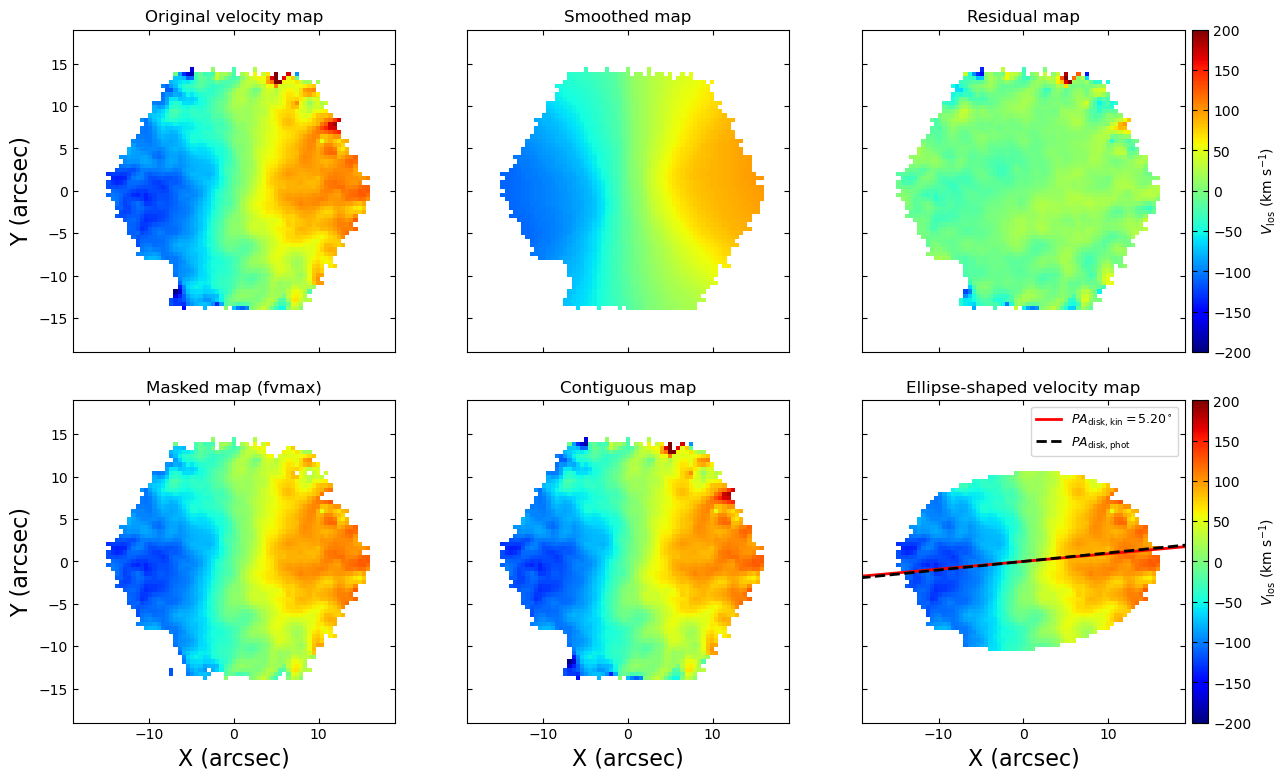

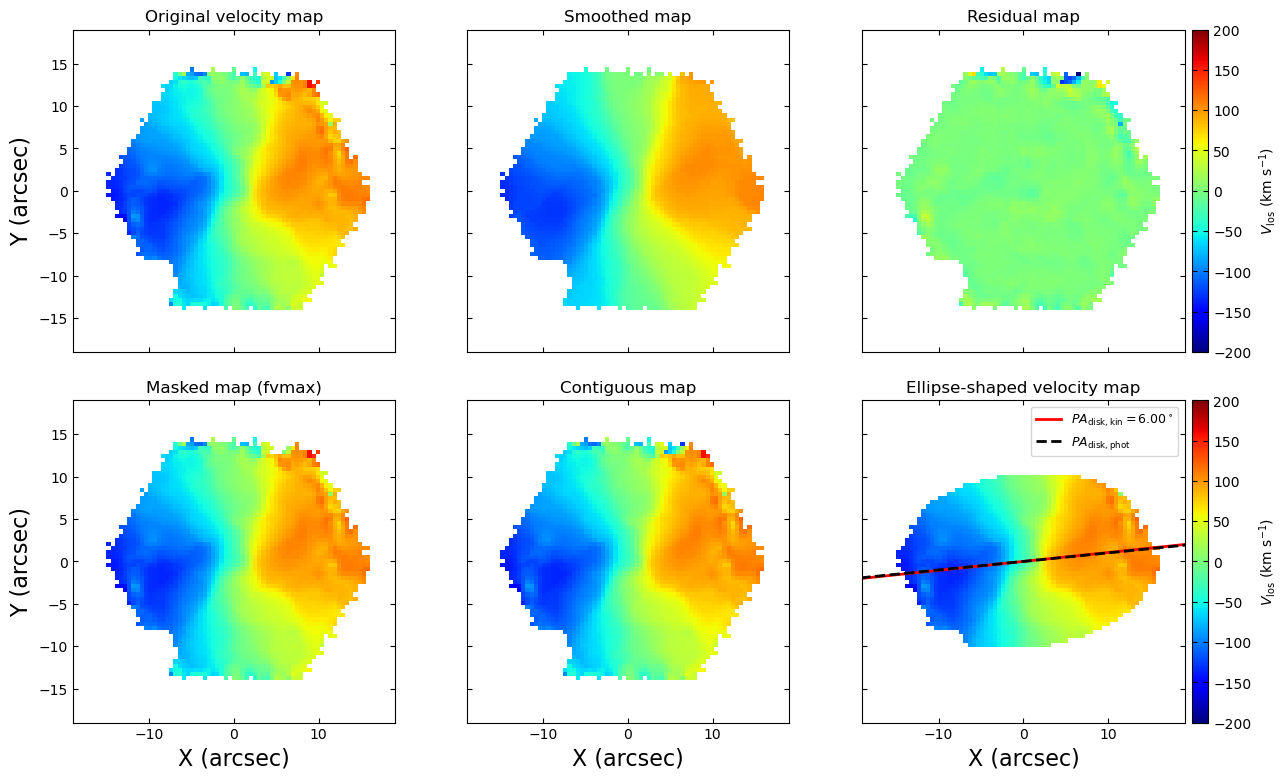

In [6]:
# =========================================================
# 6. Parameter-grid scan for PA_disk,kin: stars and H-alpha
# =========================================================
if RUN_PA_SCAN:
    results_star = Scan_PA_parameter_grid(
        v_input=stellar_vel,
        pa0_deg=PA_disk_phot,
        ellipticity=e_disk,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        center_index=center_index,
        v_extreme=V_EXTREME,
        pixscale_arcsec=pixscale,
        parallel=bool(USE_PARALLEL),
    )
    summary_star = Summarize_PA_results(results_star, round_bin_deg=ROUND_BIN_DEG)
    best_star = Pick_result_near_mode(results_star, summary_star)

    plot_PA_diagnostics_six(
        result=best_star,
        extent_arcsec=extent_arcsec,
        PA_disk_phot=PA_disk_phot,
        PA_disk_paper=PA_disk_paper,
        pa_line_key="PA_final",
    )

if RUN_HA_SCAN:
    results_ha = Scan_PA_parameter_grid(
        v_input=ha_vel,
        pa0_deg=PA_disk_phot,
        ellipticity=e_disk,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        center_index=center_index,
        v_extreme=V_EXTREME,
        pixscale_arcsec=pixscale,
        parallel=bool(USE_PARALLEL),
    )
    summary_ha = Summarize_PA_results(results_ha, round_bin_deg=ROUND_BIN_DEG)
    best_ha = Pick_result_near_mode(results_ha, summary_ha)

    plot_PA_diagnostics_six(
        result=best_ha,
        extent_arcsec=extent_arcsec,
        PA_disk_phot=PA_disk_phot,
        PA_disk_paper=PA_disk_paper,
    )


## 7. Save PA_DISK outputs

In [ ]:
# =========================================================
# 7. Save PA scan + PA summary + update master_table.csv
# =========================================================
pa_scan_cache_file = save_pa_scan_results(
    results_star,
    results_ha,
    galaxy_id=galaxy_id,
    outdir=PA_SCAN_DIR,
    extra_meta={
        "daptype": DAPTYPE,
        "maps_file": str(maps_file),
        "modelcube_file": str(modelcube_file),
        "PA_disk_phot_internal_deg": float(PA_disk_phot),
        "e_disk": float(e_disk),
        "parallel": bool(USE_PARALLEL),
    },
)

pa_summary_payload, pa_summary_file = save_pa_disk_summary(
    plateifu=galaxy_id,
    summary_star=summary_star,
    best_star=best_star,
    ellipse_payload=ellipse_payload,
    pa_scan_cache_file=pa_scan_cache_file,
    outdir=PA_DIR,
)

# Store [0,180) displayed PA convention in master table for downstream notebooks.
master_row_update = {
    "plateifu": galaxy_id,
    "Vsys_ref": float(vSyst) if np.isfinite(vSyst) else np.nan,
    "PA_disk_kin_mode_deg_0_180": float(pa_summary_payload["PA_disk_kin_mode_deg_0_180"] + 90.0) % 180.0,
    "PA_disk_kin_cmed_deg_0_180": float(pa_summary_payload["PA_disk_kin_cmed_deg_0_180"] + 90.0) % 180.0,
    "PA_disk_kin_std_deg": float(pa_summary_payload["PA_disk_kin_std_deg"]),
    "phi_bar_disk_deg": float(pa_summary_payload["phi_bar_disk_deg"]),
    "bar_half_width_arcsec": float(pa_summary_payload["bar_half_width_arcsec"]),
    "pa_scan_cache_file": str(pa_scan_cache_file),
    "pa_summary_file": str(pa_summary_file),
    "pa_disk_updated_at": pa_summary_payload["updated_at"],
}
upsert_master_row(MASTER_CSV, master_row_update, key="plateifu")

print("bar_half_width_arcsec =", pa_summary_payload["bar_half_width_arcsec"])
print("Saved PA summary      =", pa_summary_file)
print("Saved PA scan cache   =", pa_scan_cache_file)


## 8. Reload and inspect saved results

Loaded from: /home/huaijin/TW_external/intermediate_cache/pa_disk/scan_results/pa_scan_results_8312-12702.pkl.gz
Vref = -8.4432557869778 km/s
Number of ha successful fits: 144
PA_ha_kin mode/cmed/std: 6.6000000000000005 5.755001091704978 3.219243890819151
Number of stellar successful fits: 144
PA_star_kin mode/cmed/std: 5.0 5.519443130699026 0.44179219489984095
95.0
96.60000000000001


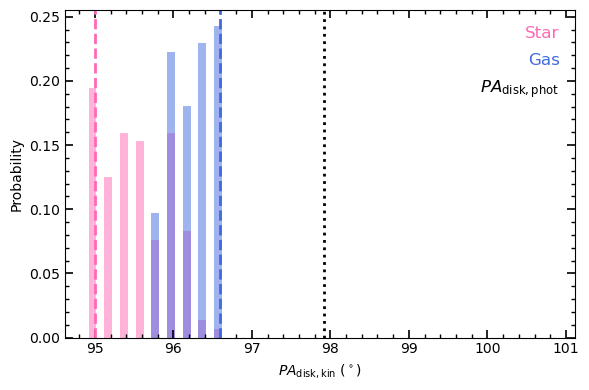

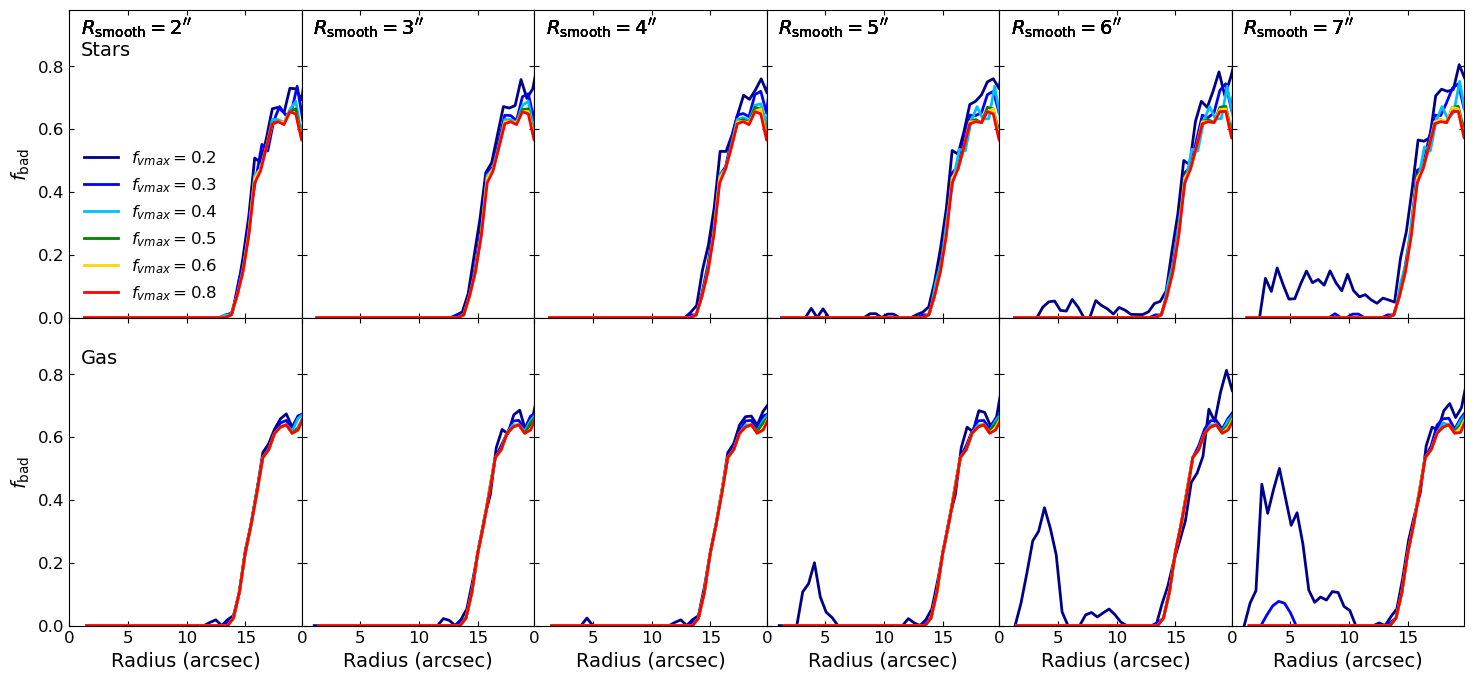

bar_half_width_arcsec from master = 4.495617912312731
PA_mode_deg internal              = 5.0


In [9]:
# =========================================================
# 8. Reload saved scan and inspect PA distributions
# =========================================================
results_star, results_ha, pa_scan_payload = load_pa_scan_results(galaxy_id=galaxy_id, outdir=PA_SCAN_DIR)
summary_star = Summarize_PA_results(results_star, round_bin_deg=HIST_ROUND_BIN_DEG)
summary_ha = Summarize_PA_results(results_ha, round_bin_deg=HIST_ROUND_BIN_DEG)
best_star = Pick_result_near_mode(results_star, summary_star)
best_ha = Pick_result_near_mode(results_ha, summary_ha)
Vref = float(best_star.get("vsys_fit", np.nan))

print("Vref =", Vref, "km/s")
print("Number of ha successful fits:", summary_ha["n_success"])
print("PA_ha_kin mode/cmed/std:", summary_ha["PA_mode"], summary_ha["PA_circ_median"], summary_ha["PA_std"])
print("Number of stellar successful fits:", summary_star["n_success"])
print("PA_star_kin mode/cmed/std:", summary_star["PA_mode"], summary_star["PA_circ_median"], summary_star["PA_std"])

plot_pa_histogram(
    np.array(summary_star["PA_list"]) + 90.0,
    np.array(summary_ha["PA_list"]) + 90.0,
    PAdisk_phot=PA_disk_phot + 90.0,
    PA_disk_paper=None if PA_disk_paper is None else PA_disk_paper + 90.0,
    bins=np.arange((PA_disk_phot + 90.0) - 3, (PA_disk_phot + 90.0) + 3, 0.1),
    round_bin_deg=summary_star["round_bin_deg"],
)

plot_fbad_figure27(results_star, results_ha)

# Use current master-table value if present.
df_master = pd.read_csv(MASTER_CSV)
master_csv_table = df_master[df_master["plateifu"].astype(str) == str(galaxy_id)].iloc[0]
bar_half_width_arcsec = float(master_csv_table["bar_half_width_arcsec"])
PA_mode_deg = float(summary_star["PA_mode"])
ra0=df_master["RA"]
dec0=df_master["DEC"]

print("bar_half_width_arcsec from master =", bar_half_width_arcsec)
print("PA_mode_deg internal              =", PA_mode_deg)


## 9. Recast-map functions

[WARNING]: All-NaN slice encountered (RuntimeWarning)


Loaded prior parameters:
  galaxy_id               = 8312-12702
  PA_disk_kin (mode)      = 5.0
  bar_half_width_arcsec   = 4.495617912312731
  PA_bar_deg_0_180        = 121.39870412540995
  a_max_arcsec            = 6.732041222374503
center_index = (37, 37)
Xref, Yref   = 0.0 0.0


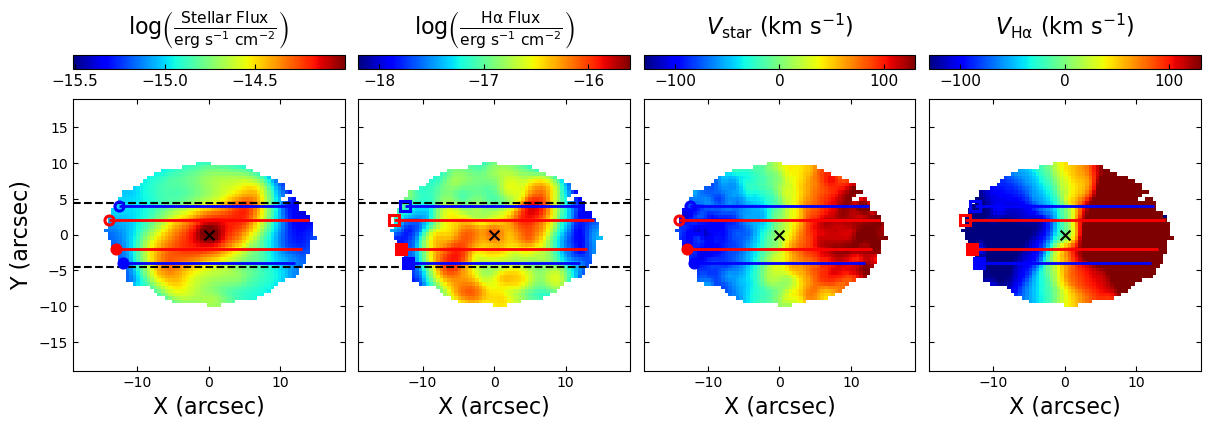

Recast stellar map ready.


In [11]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
#------------------------------------------------------------
#                       Recast vmap
#------------------------------------------------------------
def infer_true_center_pix_from_xy(x_arcsec, y_arcsec, pixel_scale=0.5):
    """
    Recover the true galaxy center in pixel coordinates from the
    already-built arcsec coordinate grids.

    Assumption:
        x_arcsec = (x_pix - x0_pix) * pixel_scale
        y_arcsec = (y_pix - y0_pix) * pixel_scale

    So:
        x0_pix = -x_arcsec[0, 0] / pixel_scale
        y0_pix = -y_arcsec[0, 0] / pixel_scale
    """
    x0_pix = -x_arcsec[0, 0] / pixel_scale
    y0_pix = -y_arcsec[0, 0] / pixel_scale
    return x0_pix, y0_pix


def _sample_with_nan_bilinear(data, x_src_pix, y_src_pix, min_valid_frac=0.999):
    """
    Bilinear interpolation with NaN-awareness.

    Strategy:
    - valid pixels contribute with weight 1
    - NaN pixels contribute with weight 0
    - only keep output pixels whose interpolated valid fraction
      is above min_valid_frac
    """
    valid = np.isfinite(data)

    data0 = np.where(valid, data, 0.0)
    w0 = valid.astype(float)

    coords = np.vstack([y_src_pix.ravel(), x_src_pix.ravel()])

    data_i = map_coordinates(
        data0, coords, order=1, mode='constant', cval=0.0
    ).reshape(data.shape)

    w_i = map_coordinates(
        w0, coords, order=1, mode='constant', cval=0.0
    ).reshape(data.shape)

    out = np.full_like(data_i, np.nan, dtype=float)
    good = w_i >= min_valid_frac
    out[good] = data_i[good] / w_i[good]

    return out, w_i

def bilinear_recast_map(
    data,
    pa_disk_deg,
    x_arcsec,
    y_arcsec,
    pixel_scale=0.5,
    min_valid_frac=0.999,
    preserve_sum=False
):
    """
    Recast a 2D map onto the aligned grid.

    Parameters
    ----------
    data : 2D array
        Original map on the native MaNGA grid.
    pa_disk_deg : float
        Disk PA in the STANDARD x-based coordinate system:
        0 deg along +X, CCW positive.
    x_arcsec, y_arcsec : 2D arrays
        Arcsec coordinate grids already centered on the true galaxy center.
        These grids define the target aligned display grid.
    pixel_scale : float
        Arcsec per pixel.
    min_valid_frac : float
        Minimum valid interpolation fraction to keep a pixel.
    preserve_sum : bool
        If True, renormalize the recast map to preserve the total sum.

    Geometry
    --------
    The target aligned grid is assumed to have the disk major axis aligned
    with +X. To sample from the original map, we rotate aligned-grid
    coordinates back into the original coordinate frame by +PA.
    """
    data = np.asarray(data, dtype=float)

    # Recover the true center in pixel coordinates
    x0_pix, y0_pix = infer_true_center_pix_from_xy(
        x_arcsec, y_arcsec, pixel_scale=pixel_scale
    )

    # Convert PA directly to radians.
    # NO legacy angle conversion is applied here.
    theta = np.deg2rad(pa_disk_deg)

    # (x_arcsec, y_arcsec) are target aligned-grid coordinates.
    # Rotate them back into the original map frame.
    x_old = x_arcsec * np.cos(theta) - y_arcsec * np.sin(theta)
    y_old = x_arcsec * np.sin(theta) + y_arcsec * np.cos(theta)

    # Convert the source-frame arcsec coordinates back to source pixels
    x_src_pix = x_old / pixel_scale + x0_pix
    y_src_pix = y_old / pixel_scale + y0_pix

    # Bilinear interpolation
    recast, valid_frac = _sample_with_nan_bilinear(
        data, x_src_pix, y_src_pix, min_valid_frac=min_valid_frac
    )

    # Optional total-sum preservation, mainly useful for flux-like maps
    if preserve_sum:
        s_in = np.nansum(data)
        s_out = np.nansum(recast)
        if np.isfinite(s_in) and np.isfinite(s_out) and s_out != 0:
            recast *= s_in / s_out

    return recast, valid_frac

def recast_binary_mask(
    mask,
    pa_disk_deg,
    x_arcsec,
    y_arcsec,
    pixel_scale=0.5,
    min_valid_frac=0.999
):
    """
    Recast a boolean mask from the original grid to the aligned grid.

    Important:
    False must be treated as NaN rather than 0.0, otherwise invalid regions
    would incorrectly act as interpolation sources.
    """
    mask = np.asarray(mask, dtype=bool)
    mask_float = np.where(mask, 1.0, np.nan)

    mask_recast_float, vf_mask = bilinear_recast_map(
        data=mask_float,
        pa_disk_deg=pa_disk_deg,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        pixel_scale=pixel_scale,
        min_valid_frac=min_valid_frac,
        preserve_sum=False
    )

    mask_recast_bool = (vf_mask >= min_valid_frac) & (mask_recast_float > 0.5)
    return mask_recast_bool, mask_recast_float, vf_mask


def recast_velocity_from_flux_and_vel(
    sigma,
    vel,
    pa_disk_deg,
    x_arcsec,
    y_arcsec,
    pixel_scale=0.5,
    min_valid_frac=0.999,
    preserve_flux_sum=True
):
    """
    Recast a flux/surface-brightness map and the corresponding velocity map.

    To preserve the luminosity-weighted velocity correctly, we recast:
        sigma
        sigma * vel
    and then divide:
        vel_recast = (sigma*vel)_recast / sigma_recast
    """
    sigma = np.asarray(sigma, dtype=float)
    vel = np.asarray(vel, dtype=float)

    sigmav = sigma * vel
    sigmav[~np.isfinite(sigma) | ~np.isfinite(vel)] = np.nan

    sigma_recast, vf_sigma = bilinear_recast_map(
        data=sigma,
        pa_disk_deg=pa_disk_deg,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        pixel_scale=pixel_scale,
        min_valid_frac=min_valid_frac,
        preserve_sum=preserve_flux_sum
    )

    sigmav_recast, vf_sigmav = bilinear_recast_map(
        data=sigmav,
        pa_disk_deg=pa_disk_deg,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        pixel_scale=pixel_scale,
        min_valid_frac=min_valid_frac,
        preserve_sum=False
    )

    vel_recast = np.full_like(sigma_recast, np.nan, dtype=float)
    good = (
        np.isfinite(sigma_recast)
        & np.isfinite(sigmav_recast)
        & (np.abs(sigma_recast) > 0)
    )
    vel_recast[good] = sigmav_recast[good] / sigma_recast[good]

    return sigma_recast, vel_recast, sigmav_recast, vf_sigma, vf_sigmav

def _ellipse_radius_recast(x_arcsec, y_arcsec, ellipticity):
    """
    Elliptical radius on the already aligned grid.

    Since the aligned grid is constructed such that the disk major axis
    lies along +X, no PA rotation is needed here.
    """
    q = max(1e-3, 1.0 - ellipticity)
    return np.sqrt(x_arcsec**2 + (y_arcsec / q)**2)

def build_display_ellipse_mask_from_valid(
    valid_mask,
    x_arcsec,
    y_arcsec,
    ellipticity,
    fbad=0.2,
    dr_arc=0.5,
    min_pix=10
):
    """
    Build an ellipse-shaped display mask from a valid-pixel mask.

    The outer ellipse is chosen such that the bad-pixel fraction in the
    corresponding elliptical annulus is as close as possible to fbad.
    """
    valid_mask = np.asarray(valid_mask, dtype=bool)
    r_ell = _ellipse_radius_recast(
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        ellipticity=ellipticity
    )

    bad = ~valid_mask
    r_max = np.nanmax(r_ell)
    r_vals = np.arange(r_max, dr_arc, -dr_arc)

    best_r = None
    best_diff = np.inf

    for r_out in r_vals:
        r_in = r_out - dr_arc
        annulus = (r_ell >= r_in) & (r_ell < r_out)
        total = np.sum(annulus)

        if total < min_pix:
            continue

        frac_bad = np.sum(bad & annulus) / total
        diff = abs(frac_bad - fbad)

        if diff < best_diff:
            best_diff = diff
            best_r = r_out

    # Fallback if no annulus is usable
    if best_r is None:
        finite_r = r_ell[valid_mask]
        if finite_r.size == 0:
            return np.zeros_like(valid_mask, dtype=bool), np.nan
        best_r = np.nanpercentile(finite_r, 95.0)

    ellipse_mask = r_ell <= best_r
    return ellipse_mask, best_r


def fixed_four_slit_segments(
    valid_mask,
    x_arcsec,
    y_arcsec,
    y_offsets_arcsec=(4.0, 2.0, -2.0, -4.0)
):
    """
    Build four fixed symmetric slits on the already aligned grid.

    We search rows closest to y = +/-4 arcsec and +/-2 arcsec, and then
    find the longest symmetric valid segment around x = 0.

    Color convention requested by the user:
    - old blue  -> dark violet
    - old red   -> hot pink
    """
    valid_mask = np.asarray(valid_mask, dtype=bool)

    # Use the coordinate axes already defined by x_arcsec / y_arcsec
    x_axis = x_arcsec[0, :]
    y_axis = y_arcsec[:, 0]
    nx = len(x_axis)

    # Find the pixel column closest to x = 0
    x0_idx = int(np.argmin(np.abs(x_axis)))

    segments = []
    for y0 in y_offsets_arcsec:
        row_idx = int(np.argmin(np.abs(y_axis - y0)))

        # Require that the nearest row is still reasonably close
        dy_local = np.abs(y_axis[row_idx] - y0)
        local_step = np.abs(y_axis[1] - y_axis[0]) if len(y_axis) > 1 else 0.5
        if dy_local > 0.51 * local_step:
            continue

        col_ok = valid_mask[row_idx, :]
        if not np.any(col_ok):
            continue

        # Expand rightward from x=0
        right = x0_idx
        while right + 1 < nx and col_ok[right + 1]:
            right += 1

        # Expand leftward from x=0
        left = x0_idx
        while left - 1 >= 0 and col_ok[left - 1]:
            left -= 1

        # Enforce symmetry about x=0
        dx = min(right - x0_idx, x0_idx - left)
        if dx < 1:
            continue

        this_color = "b" if abs(y0) == 4.0 else "red"

        segments.append({
            "y0": y_axis[row_idx],
            "x_left": x_axis[x0_idx - dx],
            "x_right": x_axis[x0_idx + dx],
            "row_idx": row_idx,
            "color": this_color,
        })

    return segments

def _safe_log_flux(arr):
    """
    Safe log10 for flux-like images.
    Non-positive and non-finite values are mapped to NaN.
    """
    out = np.array(arr, dtype=float, copy=True)
    bad = ~np.isfinite(out) | (out <= 0)
    out[bad] = np.nan
    out[~bad] = np.log10(out[~bad])
    return out

def _draw_slits(ax, segments, tracer="stellar", lw=2.0, ms=6.5, mew=2.0):
    """
    Draw slit center lines and endpoint markers.

    Requested visual changes:
    - marker edges are thicker
    - colors are b / red
    """
    marker = "o" if tracer == "stellar" else "s"

    for seg in segments:
        ax.plot(
            [seg["x_left"], seg["x_right"]],
            [seg["y0"], seg["y0"]],
            color=seg["color"],
            lw=lw,
            solid_capstyle="butt",
            zorder=5
        )

        is_upper = seg["y0"] > 0

        # Endpoints:
        # upper slit: open marker
        # lower slit: filled marker
        ax.plot(
            seg["x_left"],
            seg["y0"],
            marker=marker,
            ms=ms,
            mec=seg["color"],
            mfc="none" if is_upper else seg["color"],
            mew=mew,                  # thicker marker edge
            color=seg["color"],
            zorder=6
        )


def _add_top_colorbar(fig, ax, im, label, ticks=None):
    """
    Add a top horizontal colorbar above a panel.
    """
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("top", size="5%", pad=0.3)

    cb = fig.colorbar(im, cax=cax, orientation="horizontal", ticks=ticks)
    cb.set_label(label, fontsize=16, labelpad=15)

    # Put the tick labels below the top colorbar
    cax.xaxis.set_ticks_position("bottom")
    cax.xaxis.set_label_position("top")

    cb.ax.tick_params(
        direction="in",
        top=False,
        bottom=True,
        labeltop=False,
        labelbottom=True,
        labelsize=11
    )
    return cb

def plot_figure4_updated(
    stellar_sigma_recast,
    stellar_vel_recast,
    ha_sigma_recast,
    ha_vel_recast,
    display_mask_star,
    display_mask_ha,
    segments,
    extent_arcsec,
    xlim=(-19, 19),
    ylim=(-19, 19),
    bar_half_width_arcsec=None,
):
    """
    Plot the four-panel Figure-4-style layout on the aligned grid.
    """
    # Apply display masks
    star_flux = np.where(display_mask_star, stellar_sigma_recast, np.nan)
    star_vel  = np.where(display_mask_star, stellar_vel_recast, np.nan)

    ha_flux = np.where(display_mask_ha, ha_sigma_recast, np.nan)
    ha_vel  = np.where(display_mask_ha, ha_vel_recast, np.nan)

    # Convert fluxes to display units if needed
    star_flux_disp = star_flux * 1e-17
    ha_flux_disp   = ha_flux * 1e-17

    fig, axes = plt.subplots(1, 4, figsize=(12, 6), sharex=True, sharey=True)

    panels = [
        (
            _safe_log_flux(star_flux_disp),
            "stellar",
            r"$\log \!\left(\frac{{\rm Stellar\ Flux}}{{\rm erg\ s^{-1}\ cm^{-2}}}\right)$",
            -15.51, -14.0, [-15.5, -15.0, -14.5]
        ),
        (
            _safe_log_flux(ha_flux_disp),
            "ha",
            r"$\log \!\left(\frac{{\rm H\alpha\ Flux}}{{\rm erg\ s^{-1}\ cm^{-2}}}\right)$",
            -18.2, -15.6, [-18.0, -17.0, -16.0]
        ),
        (
            star_vel,
            "stellar",
            r"$V_{\rm star}\ ({\rm km\ s^{-1}})$",
            -130, 130, [-100, 0, 100]
        ),
        (
            ha_vel,
            "ha",
            r"$V_{\rm H\alpha}\ ({\rm km\ s^{-1}})$",
            -130, 130, [-100, 0, 100]
        ),
    ]

    ims = []
    for ax, (img, tracer, cblabel, vmin, vmax, ticks) in zip(axes, panels):
        ax.scatter(0,0,marker='x',color='black',s=50,label='Galaxy center')
        im = ax.imshow(
            img,
            origin="lower",
            extent=extent_arcsec,
            cmap="jet",
            vmin=vmin,
            vmax=vmax,
            aspect="equal"
        )

        _draw_slits(
            ax,
            segments,
            tracer=tracer,
            lw=2.0,
            ms=6.5,
            mew=2.2   # thicker marker edge as requested
        )
        # 在前两幅图上画 bar half-width guide lines
        if (bar_half_width_arcsec is not None) and np.isfinite(bar_half_width_arcsec):
            panel_index = len(ims)   # 当前是第几幅，0,1,2,3
            if panel_index in (0, 1):
                ax.axhline(+bar_half_width_arcsec, color='black', linestyle='--', linewidth=1.5)
                ax.axhline(-bar_half_width_arcsec, color='black', linestyle='--', linewidth=1.5)

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel("X (arcsec)", fontsize=16)
        ax.tick_params(direction="in", top=True, right=True)

        ims.append((im, cblabel, ticks))

    axes[0].set_ylabel("Y (arcsec)", fontsize=16)

    for ax, (im, cblabel, ticks) in zip(axes, ims):
        _add_top_colorbar(fig, ax, im, cblabel, ticks=ticks)

    plt.subplots_adjust(
        wspace=0.05,
        left=0.055,
        right=0.995,
        bottom=0.12,
        top=0.70
    )
    return fig, axes

def make_figure4_from_original_maps(
    stellar_sigma,
    stellar_vel,
    ha_sigma,
    ha_vel,
    pa_disk_kin,
    e_disk,
    x_arcsec,
    y_arcsec,
    extent_arcsec,
    pixel_scale=0.5,
    min_valid_frac=0.999,
    fbad=0.2,
    dr_arc=0.5,
    min_pix=10,
    cached_mask_result=None,
    cached_mask_key="fit_valid_mask_final",
    bar_half_width_arcsec=None,
):
    """
    Build the Figure-4-style products directly from the ORIGINAL maps,
    using the already defined true-center coordinate system.

    IMPORTANT:
    - No legacy center=None logic is kept.
    - No old geometric-center fallback is kept.
    - The aligned grid is fully defined by x_arcsec / y_arcsec / extent_arcsec.
    - PA is assumed to be already in the standard x-based convention.
    """
    # ===== recast the stellar maps =====
    sigma_star_r, vel_star_r, sigmav_star_r, vf_sigma_star, vf_sigmav_star = recast_velocity_from_flux_and_vel(
        sigma=stellar_sigma,
        vel=stellar_vel,
        pa_disk_deg=pa_disk_kin,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        pixel_scale=pixel_scale,
        min_valid_frac=min_valid_frac,
        preserve_flux_sum=True
    )

    # ===== recast the Halpha maps =====
    sigma_ha_r, vel_ha_r, sigmav_ha_r, vf_sigma_ha, vf_sigmav_ha = recast_velocity_from_flux_and_vel(
        sigma=ha_sigma,
        vel=ha_vel,
        pa_disk_deg=pa_disk_kin,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        pixel_scale=pixel_scale,
        min_valid_frac=min_valid_frac,
        preserve_flux_sum=True
    )

    # ===== valid masks after recasting =====
    stellar_valid_recast = (
        (vf_sigma_star >= min_valid_frac)
        & (vf_sigmav_star >= min_valid_frac)
        & np.isfinite(sigma_star_r)
        & np.isfinite(vel_star_r)
    )

    ha_valid_recast = (
        (vf_sigma_ha >= min_valid_frac)
        & (vf_sigmav_ha >= min_valid_frac)
        & np.isfinite(sigma_ha_r)
        & np.isfinite(vel_ha_r)
    )

    # ===== preferred path: use the cached final mask tied to the adopted PA =====
    if cached_mask_result is not None:
        if cached_mask_key not in cached_mask_result:
            raise KeyError(f"{cached_mask_key} not found in cached_mask_result.")

        cached_mask_orig = cached_mask_result[cached_mask_key]

        geometry_mask_recast, _, vf_cached = recast_binary_mask(
            mask=cached_mask_orig,
            pa_disk_deg=pa_disk_kin,
            x_arcsec=x_arcsec,
            y_arcsec=y_arcsec,
            pixel_scale=pixel_scale,
            min_valid_frac=min_valid_frac
        )

        r_ell = _ellipse_radius_recast(
            x_arcsec=x_arcsec,
            y_arcsec=y_arcsec,
            ellipticity=e_disk
        )
        a_ell = np.nanmax(r_ell[geometry_mask_recast]) if np.any(geometry_mask_recast) else np.nan

    else:
        # ===== fallback: estimate a display ellipse directly from the current valid region =====
        valid_union = stellar_valid_recast & ha_valid_recast

        geometry_mask_recast, a_ell = build_display_ellipse_mask_from_valid(
            valid_mask=valid_union,
            x_arcsec=x_arcsec,
            y_arcsec=y_arcsec,
            ellipticity=e_disk,
            fbad=fbad,
            dr_arc=dr_arc,
            min_pix=min_pix
        )

    # ===== build tracer-specific display masks =====
    display_mask_star = geometry_mask_recast & stellar_valid_recast
    display_mask_ha   = geometry_mask_recast & ha_valid_recast

    # ===== define a common slit-valid mask so all panels use identical slit lengths =====
    slit_mask_common = geometry_mask_recast & stellar_valid_recast & ha_valid_recast

    segments = fixed_four_slit_segments(
        valid_mask=slit_mask_common,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        y_offsets_arcsec=(4.0, 2.0, -2.0, -4.0)
    )

    fig, axes = plot_figure4_updated(
        stellar_sigma_recast=sigma_star_r,
        stellar_vel_recast=vel_star_r,
        ha_sigma_recast=sigma_ha_r,
        ha_vel_recast=vel_ha_r,
        display_mask_star=display_mask_star,
        display_mask_ha=display_mask_ha,
        segments=segments,
        extent_arcsec=extent_arcsec,
        xlim=(-19, 19),
        ylim=(-19, 19),
        bar_half_width_arcsec=bar_half_width_arcsec,
    )

    return {
        "stellar_sigma_recast": sigma_star_r,
        "stellar_vel_recast": vel_star_r,
        "ha_sigma_recast": sigma_ha_r,
        "ha_vel_recast": vel_ha_r,

        "vf_sigma_star": vf_sigma_star,
        "vf_sigmav_star": vf_sigmav_star,
        "vf_sigma_ha": vf_sigma_ha,
        "vf_sigmav_ha": vf_sigmav_ha,

        "geometry_mask_recast": geometry_mask_recast,
        "display_mask_star": display_mask_star,
        "display_mask_ha": display_mask_ha,
        "slit_mask_common": slit_mask_common,
        "bar_half_width_arcsec": bar_half_width_arcsec,
        
        "ellipse_a_arcsec": a_ell,
        "segments": segments,
        "figure": fig,
        "axes": axes,
    }

    master_csv = Path(master_csv)

    if master_csv.exists():
        df = pd.read_csv(master_csv)
    else:
        df = pd.DataFrame()

    row_df = pd.DataFrame([row_dict])

    if df.empty:
        df = row_df.copy()
    else:
        if key not in df.columns:
            df[key] = None

        row_key = row_dict[key]
        mask = df[key].astype(str) == str(row_key)

        for col in row_df.columns:
            if col not in df.columns:
                df[col] = pd.NA
        for col in df.columns:
            if col not in row_df.columns:
                row_df[col] = pd.NA

        row_df = row_df[df.columns]

        if mask.any():
            idx = df.index[mask][0]
            for col, val in row_dict.items():
                df.loc[idx, col] = val
        else:
            df = pd.concat([df, row_df], ignore_index=True)

    df.to_csv(master_csv, index=False)
    print(f"Updated master table: {master_csv}")
    return df

def pick_result_near_mode(results, summary):
    """
    从所有结果中挑一个最靠近 mode bin 且误差最小的结果。
    """
    round_bin_deg = summary.get("round_bin_deg", 1.0)
    target_mode = angle_wrapto_180(summary["PA_mode"])

    candidates = []
    for r in results:
        if (not r["success"]) or (not np.isfinite(r["PA_final"])):
            continue

        pa_bin = round(r["PA_final"] / round_bin_deg) * round_bin_deg
        pa_bin = angle_wrapto_180(pa_bin)

        if pa_bin == target_mode:
            candidates.append(r)

    if len(candidates) == 0:
        raise ValueError("No result found in the PA_mode bin.")

    candidates = sorted(
        candidates,
        key=lambda r: (
            np.inf if not np.isfinite(r["PA_err"]) else r["PA_err"],
            -r.get("n_good", 0)
        )
    )
    return candidates[0]

# =========================================================
# 0. basic setup
# =========================================================
galaxy_id = "8312-12702"
pixscale = 0.5   # arcsec / pix for MaNGA reconstructed cube
Re=7.67477

CACHE_ROOT = Path("/home/huaijin/TW_external/intermediate_cache")
ELLIPSE_DIR = CACHE_ROOT / "ellipse"
PA_DIR = CACHE_ROOT / "pa_disk"
MASTER_CSV = CACHE_ROOT / "master_table.csv"
TW_CENTER_DIR = CACHE_ROOT / "tw_center"
TW_CENTER_DIR.mkdir(parents=True, exist_ok=True)

def load_json(path):
    path = Path(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

# =========================================================
# 1. load previous cached parameters
# =========================================================
# ellipse_payload = load_ellipse_result(galaxy_id)
# pa_summary_payload = load_json(PA_DIR / f"pa_disk_summary_{galaxy_id}.json")
# results_star, results_ha, payload = load_pa_scan_results(galaxy_id=galaxy_id)

# summary_star = Summarize_PA_results(results_star, round_bin_deg=1.0)
# best_star = pick_result_near_mode(results_star, summary_star)
# Vref = float(best_star["vsys_fit"])
# print("Vref =", Vref, "km/s")
'''
results_star, results_ha, payload = load_pa_scan_results(galaxy_id=galaxy_id)
summary_star = Summarize_PA_results(results_star, round_bin_deg=1.0)

vsys_candidates = np.array([
    r["vsys_fit"]
    for r in results_star
    if np.isfinite(r.get("PA_final", np.nan))
    and np.isfinite(r.get("vsys_fit", np.nan))
    and abs(r["PA_final"] - summary_star["PA_mode"]) <= 0.5
], dtype=float)

Vref = float(np.nanmedian(vsys_candidates))
print("Vref from near-PA_mode median =", Vref, "km/s")
print("N(vsys candidates) =", len(vsys_candidates))
'''
PA_disk_kin = float(summary_star["PA_mode"])
bar_half_width_arcsec = float(bar_half_width_arcsec)

print("Loaded prior parameters:")
print("  galaxy_id               =", galaxy_id)
print("  PA_disk_kin (mode)      =", PA_disk_kin)
print("  bar_half_width_arcsec   =", bar_half_width_arcsec)
print("  PA_bar_deg_0_180        =", ellipse_payload["PA_bar_deg_0_180"])
print("  a_max_arcsec            =", ellipse_payload["a_max_arcsec"])


def nanmedian_filter(data, size):

    # 对含 NaN 的数组做 nanmedian 滤波。
    return generic_filter(data,function=lambda x: np.nanmedian(x),size=size,mode='nearest')

def velocity_smooth_island_precompute(
    v0,
    Rsmooth_arcsec,fvmax, center_index,
    pixscale_arcsec=0.5,):
    """
    对给定速度图做一次预计算：
    1) 中值平滑
    2) residual 与 bad mask
    3) 寻找与中心像素连通的 mainland

    这里输入的 center_index 已经是根据真实中心得到的最近像素索引，
    因此不再保留 center=None 和几何中心 fallback 的旧逻辑。
    """
    cy, cx = center_index

    # 将平滑半径（arcsec）换算成像素，再转成方窗大小
    Rsmooth_pix = Rsmooth_arcsec / pixscale_arcsec
    size = int(2 * Rsmooth_pix + 1)
    size = max(3, size)

    mask = np.isfinite(v0)
    vmap = v0.copy()
    vmap[~mask] = np.nan

    # 对速度图做 nanmedian 平滑
    v_smooth = nanmedian_filter(vmap, size=size)
    v_smooth[~mask] = np.nan

    # 取平滑图的最大幅值，作为 residual 的归一化尺度
    Vmax = np.nanmax(np.abs(v_smooth))
    residual = v0 - v_smooth

    # 超过 fvmax * Vmax 的 residual 视为坏点
    if np.isfinite(Vmax) and Vmax > 0:
        bad = np.abs(residual) / Vmax > fvmax
    else:
        bad = np.zeros_like(v0, dtype=bool)

    bad |= ~np.isfinite(v0)

    # 连通域：只保留与中心相连的最大主块
    valid_land = np.isfinite(v0)
    labels, nlab = label(valid_land)

    if nlab == 0:
        mainland = np.zeros_like(v0, dtype=bool)
        print("Caution: No valid mainland")
    else:
        center_label = labels[cy, cx]

        if center_label != 0:
            # 中心像素本身就在某个连通域里，则直接取这个连通域
            mainland = (labels == center_label)
        else:
            # 如果中心像素恰好落在 NaN 或断裂处，则退一步取最大的非零连通域
            print("Caution: Center pixel is not inside a valid island; using the largest island.")
            counts = np.bincount(labels.ravel())
            counts[0] = 0
            lab = np.argmax(counts)
            mainland = (labels == lab)

    return {
        "bad": bad,
        "Vmax": Vmax,
        "residual": residual,
        "v_smooth": v_smooth,
        "mainland": mainland,
    }


def elliptical_radius_from_xy_arcsec(x_arcsec, y_arcsec, pa_deg, ellipticity):
    """
    计算在给定 PA 和椭率下的椭圆半径，输入/输出都用 arcsec。

    这里的 pa_deg 是外部/论文 PA；
    函数内部自动转换到数学角 theta 再进行旋转。
    """
    q = max(1e-3, 1.0 - ellipticity)

    # 把外部 PA 转为内部数学角
    theta = np.radians(pa_deg)
#    print(f'elliptical_radius_from_xy_arcsec',theta*180/np.pi)
    # 将点旋转到椭圆主轴坐标系
    x_rot = x_arcsec * np.cos(theta) + y_arcsec * np.sin(theta)
    y_rot = -x_arcsec * np.sin(theta) + y_arcsec * np.cos(theta)

    # 椭圆半径（半长轴尺度）
    r_ell = np.sqrt(x_rot**2 + (y_rot / q)**2)
    return r_ell

def ellipse_mask_from_precomputed(
    v0,
    x_arcsec,
    y_arcsec,
    pa_deg,
    ellipticity,
    precomp,
    fbad=0.2,
    dr_arcsec=0.5,
    min_pix=10,
    remove_bar=False,
    bar_r_arcsec=0.0,
):
    """
    在给定 PA / ellipticity 下，根据 bad-pixel fraction 的径向分布，
    寻找一个最佳椭圆截断半径 r_cut，并返回对应的椭圆 mask。

    这一版里 x/y 是 arcsec，因此 r_ell 与 dr_arcsec 都直接在同一单位里。
    """
    bad = precomp["bad"]
    mainland = precomp["mainland"]

    # 直接在 arcsec 坐标上求椭圆半径
    r_ell = elliptical_radius_from_xy_arcsec(
        x_arcsec, y_arcsec, pa_deg, ellipticity
    )

    masked_total = bad | (~mainland)

    r_max = np.nanmax(r_ell)
    r_vals = np.arange(r_max, dr_arcsec, -dr_arcsec)

    best_r = None
    best_diff = np.inf

    frac_profile = []
    r_mid_list = []

    for r_out in r_vals:
        r_in = r_out - dr_arcsec

        annulus = (r_ell >= r_in) & (r_ell < r_out)

        total = np.sum(annulus)
        if total < min_pix:
            continue

        frac_bad = np.sum(masked_total & annulus) / total
        r_mid = 0.5 * (r_in + r_out)

        frac_profile.append(frac_bad)
        r_mid_list.append(r_mid)

        diff = np.abs(frac_bad - fbad)
        if diff < best_diff:
            best_diff = diff
            best_r = r_out

    r_cut = best_r
    ell_mask = r_ell < r_cut if best_r is not None else np.zeros_like(v0, dtype=bool)

    # 如果你希望把 bar 区域剔掉，则要求 bar_r_arcsec 也用 arcsec 传入
    if remove_bar and bar_r_arcsec > 0:
        ell_mask &= (r_ell >= bar_r_arcsec)
        
    return {
        "ellipse_mask": ell_mask,
        "r_cut": r_cut,
        "r_ell": r_ell,
        "r_mid_profile": np.array(r_mid_list),
        "frac_profile": np.array(frac_profile),
    }

def rebuild_exact_mode_mask_from_best_params(
    v_input,
    pa_mode_deg,
    ellipticity,
    x_arcsec,
    y_arcsec,
    center_index,
    result_best,
    v_extreme=300,
    dr_arcsec=0.5,
    min_pix=10,
    remove_bar=False,
    bar_r_arcsec=0.0,
    pixscale_arcsec=0.5,
):
    """
    用“best result 的最优 Rsmooth/fvmax/fbad 参数组合”，
    但在“精确 PA_mode”上重建一次最终 mask。

    这样 Figure 4 中使用的 geometry mask 就与：
      - 真实中心原点
      - 最终 adopted PA_mode
    严格一致。

    Parameters
    ----------
    result_best : dict
        通常来自 pick_result_near_mode(results_star, summary_star)
        其中提供 Rsmooth_arcsec / fvmax / fbad.
    """

    Rsmooth_arcsec = float(result_best["Rsmooth_arcsec"])
    fvmax = float(result_best["fvmax"])
    fbad = float(result_best["fbad"])

    pa_mode_deg = angle_wrapto_180(pa_mode_deg)

    # 1) 基础清洗
    v0 = robust_velocity_clean(v_input, v_extreme=v_extreme)

    # 2) 用 best 的 smooth/island 参数重建 precompute
    precomp = velocity_smooth_island_precompute(
        v0=v0,
        Rsmooth_arcsec=Rsmooth_arcsec,
        fvmax=fvmax,
        center_index=center_index,
        pixscale_arcsec=pixscale_arcsec,
    )

    # 3) 但 ellipse mask 使用“精确 PA_mode”
    ell = ellipse_mask_from_precomputed(
        v0=v0,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        pa_deg=pa_mode_deg,
        ellipticity=ellipticity,
        precomp=precomp,
        fbad=fbad,
        dr_arcsec=dr_arcsec,
        min_pix=min_pix,
        remove_bar=remove_bar,
        bar_r_arcsec=bar_r_arcsec,
    )

    bad = precomp["bad"]
    mainland = precomp["mainland"]
    masked_total = bad | (~mainland)

    fit_valid_mask_final = (~masked_total) & ell["ellipse_mask"]

    final_map_pa_mode = v0.copy()
    final_map_pa_mode[~fit_valid_mask_final] = np.nan

    return {
        "success": True,
        "PA_final": pa_mode_deg,
        "PA_err": np.nan,
        "vsys_fit": np.nan,
        "n_good": int(np.sum(np.isfinite(final_map_pa_mode))),

        "Rsmooth_arcsec": Rsmooth_arcsec,
        "Rsmooth_pix": Rsmooth_arcsec / pixscale_arcsec,
        "fvmax": fvmax,
        "fbad": fbad,

        "v_original": v0,
        "v_smooth": precomp["v_smooth"],
        "residual": precomp["residual"],
        "v_masked_fvmax": np.where(bad, np.nan, v0),
        "v_contiguous": np.where(mainland, v0, np.nan),

        "v_ellipse": final_map_pa_mode,
        "ellipse_mask": ell["ellipse_mask"],
        "fit_valid_mask_final": fit_valid_mask_final,
        "r_cut": ell["r_cut"],
        "r_ell": ell["r_ell"],
        "r_mid_profile": ell["r_mid_profile"],
        "frac_profile": ell["frac_profile"],

        "bad_mask": bad,
        "mainland_mask": mainland,
        "center_index": center_index,

        "rebuilt_from_result_best": True,
        "source_PA_mode": pa_mode_deg,
    }


# =========================================================
# 4. true center from RA/Dec  ->  Xref, Yref coordinate system
# =========================================================

x_pix, y_pix = wcs2d.world_to_pixel_values(ra0, dec0)

x_arcsec, y_arcsec, extent_arcsec, center_index = Build_xy_arcsec_with_center(
    shape=stellar_surfb.shape,
    x0_pix=x_pix,
    y0_pix=y_pix,
    pixscale_arcsec=pixscale
)

# In this coordinate system:
#   Xref = 0 arcsec
#   Yref = 0 arcsec
Xref_arcsec = 0.0
Yref_arcsec = 0.0

print("center_index =", center_index)
print("Xref, Yref   =", Xref_arcsec, Yref_arcsec)

# =========================================================
# 5. exact PA_mode mask rebuild + Figure-4-style recast maps
# =========================================================
e_disk = float(ellipse_payload["e_disk"])

result_star_exact_mode = rebuild_exact_mode_mask_from_best_params(
    v_input=stellar_vel,
    pa_mode_deg=PA_disk_kin,
    ellipticity=e_disk,
    x_arcsec=x_arcsec,
    y_arcsec=y_arcsec,
    center_index=center_index,
    result_best=best_star,
    v_extreme=300,
    dr_arcsec=0.5,
    min_pix=10,
    remove_bar=False,
    bar_r_arcsec=0.0,
    pixscale_arcsec=pixscale,
)

fig4_out = make_figure4_from_original_maps(
    stellar_sigma=stellar_surfb,
    stellar_vel=stellar_vel,
    ha_sigma=ha_flux,
    ha_vel=ha_vel,
    pa_disk_kin=PA_disk_kin,
    e_disk=e_disk,
    x_arcsec=x_arcsec,
    y_arcsec=y_arcsec,
    extent_arcsec=extent_arcsec,
    pixel_scale=pixscale,
    min_valid_frac=0.999,
    fbad=0.2,
    dr_arc=0.5,
    min_pix=10,
    cached_mask_result=result_star_exact_mode,
    cached_mask_key="fit_valid_mask_final",
    bar_half_width_arcsec=bar_half_width_arcsec,
)

plt.show()

# Recasted stellar map used below
stellar_sigma_recast = fig4_out["stellar_sigma_recast"]
ha_sigma_recast = fig4_out["ha_sigma_recast"]
# IMPORTANT:
# For this Yc / Eq.6 step, I use the stellar-only valid mask,
# because here Σ is the stellar surface brightness.
valid_mask_star = fig4_out["display_mask_star"]
valid_mask_ha = fig4_out["display_mask_ha"]
x_axis = x_arcsec[0, :].astype(float)
y_axis = y_arcsec[:, 0].astype(float)

print("Recast stellar map ready.")

## 10. Nominal recast product

Saved nominal recast product: /home/huaijin/TW_external/intermediate_cache/recast/recast_8312-12702_PA_DISK.pkl
Keys: ['bar_half_width_arcsec', 'display_mask_ha', 'display_mask_star', 'ellipse_a_arcsec', 'geometry_mask_recast', 'ha_sigma_recast', 'ha_vel_recast', 'segments', 'slit_mask_common', 'stellar_sigma_recast', 'stellar_vel_recast', 'vf_sigma_ha', 'vf_sigma_star', 'vf_sigmav_ha', 'vf_sigmav_star']


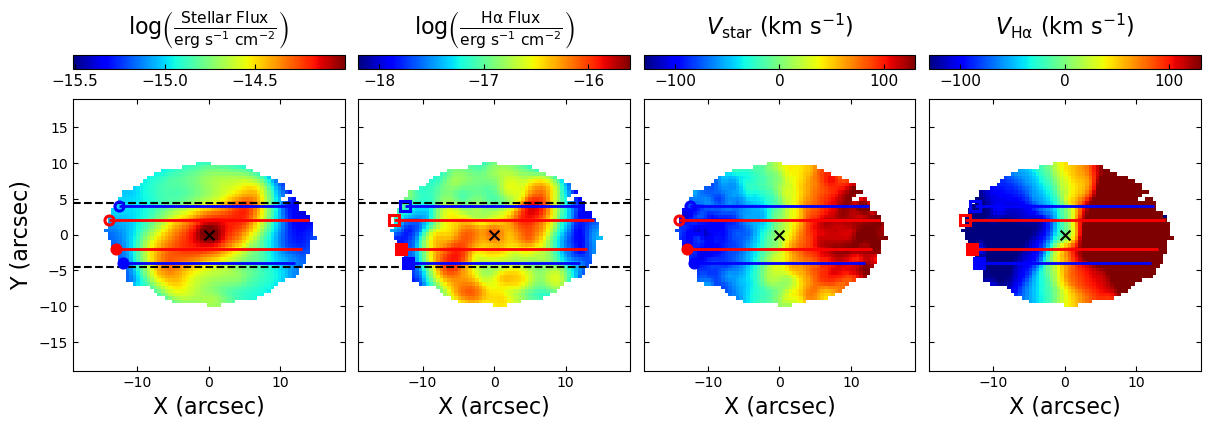

In [12]:
# =========================================================
# 10. Recast maps and save nominal Figure-4 product
# =========================================================
fig4_out = make_figure4_from_original_maps(
    stellar_sigma=stellar_surfb,
    stellar_vel=stellar_vel,
    ha_sigma=ha_flux,
    ha_vel=ha_vel,
    pa_disk_kin=PA_mode_deg,
    e_disk=e_disk,
    x_arcsec=x_arcsec,
    y_arcsec=y_arcsec,
    extent_arcsec=extent_arcsec,
    pixel_scale=pixscale,
    min_valid_frac=0.999,
    fbad=0.2,
    dr_arc=0.5,
    min_pix=10,
    cached_mask_result=best_star,
    cached_mask_key="fit_valid_mask_final",
    bar_half_width_arcsec=bar_half_width_arcsec,
)

# Save lightweight non-figure product for downstream TW notebooks.
recast_outfile = RECAST_DIR / f"recast_{galaxy_id}_PA_DISK.pkl"
fig4_out_to_save = {k: v for k, v in fig4_out.items() if k not in ["figure", "axes"]}
with open(recast_outfile, "wb") as f:
    pickle.dump(fig4_out_to_save, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved nominal recast product:", recast_outfile)
print("Keys:", sorted(fig4_out_to_save.keys()))


## 11. PA_disk Monte Carlo functions

In [13]:
import numpy as np
import pandas as pd
import json
from pathlib import Path
from datetime import datetime

# ================================
# 2. 生成 PA_disk,kin 的 Monte Carlo 样本
# ================================
def generate_pa_disk_mc_samples(
    summary_star,
    n_mc=100,
    seed=42,
    use_center="circ_median",   # "circ_median" or "mode"
    outdir=".",
    plateifu=None,
    save_prefix="PA_disk_kin_MC",
):
    """
    Generate Monte Carlo realizations for PA_disk,kin.

    Parameters
    ----------
    summary_star : dict
        Your summary dict, expected keys:
        - "PA_mode"
        - "PA_circ_median"
        - "PA_std"
        - "PA_list" (optional, only for metadata)
    n_mc : int
        Number of Monte Carlo realizations.
    seed : int
        Random seed for reproducibility.
    use_center : str
        Center of the Gaussian sampling:
        - "circ_median": recommended
        - "mode": if you want to stay maximally consistent with adopted PA
    outdir : str
        Output directory.
    plateifu : str or None
        Optional plateifu, used in file names.
    save_prefix : str
        Prefix for saved files.

    Returns
    -------
    pa_mc : ndarray, shape (n_mc,)
        Wrapped PA samples in [0, 180).
    df_mc : pandas.DataFrame
        Table with sample_id and PA_disk_kin_MC_deg.
    meta : dict
        Metadata used for the sampling.
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    pa_mode = float(summary_star["PA_mode"])
    pa_cmed = float(summary_star["PA_circ_median"])
    pa_std  = float(summary_star["PA_std"])

    if not np.isfinite(pa_std) or pa_std <= 0:
        raise ValueError(f"Invalid PA_std = {pa_std}. Cannot generate MC samples.")

    if use_center == "circ_median":
        center = pa_cmed
    elif use_center == "mode":
        center = pa_mode
    else:
        raise ValueError("use_center must be 'circ_median' or 'mode'.")

    rng = np.random.default_rng(seed)

    # Gaussian draw around center
    # Since your PA is far from the 0/180 boundary and sigma is very small,
    # simple Gaussian + wrap is fully adequate here.
    raw = rng.normal(loc=center, scale=pa_std, size=n_mc)
    pa_mc = angle_wrapto_180(raw)

    # Pack into DataFrame
    df_mc = pd.DataFrame({
        "sample_id": np.arange(n_mc, dtype=int),
        "PA_disk_kin_MC_deg": pa_mc,
        "delta_from_center_deg": np.array([angle_diff_deg(x, center) for x in pa_mc]),
    })

    # Metadata
    meta = {
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "plateifu": None if plateifu is None else str(plateifu),
        "n_mc": int(n_mc),
        "seed": int(seed),
        "sampling_center_type": str(use_center),
        "sampling_center_deg": float(center),
        "PA_mode_deg": pa_mode,
        "PA_circ_median_deg": pa_cmed,
        "PA_std_deg": pa_std,
        "PA_list_size": int(len(summary_star.get("PA_list", []))),
        "recommended_sigma_range_deg": [float(center - pa_std), float(center + pa_std)],
        "recommended_3sigma_range_deg": [float(center - 3*pa_std), float(center + 3*pa_std)],
    }

    # File names
    tag = "" if plateifu is None else f"_{plateifu}"
    npz_file  = outdir / f"{save_prefix}{tag}.npz"
    csv_file  = outdir / f"{save_prefix}{tag}.csv"
    json_file = outdir / f"{save_prefix}{tag}_meta.json"

    # Save
    np.savez(
        npz_file,
        PA_disk_kin_MC_deg=pa_mc,
        sample_id=df_mc["sample_id"].to_numpy(),
        delta_from_center_deg=df_mc["delta_from_center_deg"].to_numpy(),
    )
    df_mc.to_csv(csv_file, index=False)

    with open(json_file, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

    print(f"[Saved] {npz_file}")
    print(f"[Saved] {csv_file}")
    print(f"[Saved] {json_file}")

    print("\nMonte Carlo summary:")
    print(f"  center type   : {use_center}")
    print(f"  center (deg)  : {center:.6f}")
    print(f"  sigma  (deg)  : {pa_std:.6f}")
    print(f"  1σ range      : [{center-pa_std:.6f}, {center+pa_std:.6f}]")
    print(f"  3σ range      : [{center-3*pa_std:.6f}, {center+3*pa_std:.6f}]")

    return pa_mc, df_mc, meta

In [15]:
# =========================================================
# 13. Build and save Recast maps for PA_disk Monte Carlo samples
# =========================================================
# Purpose:
#   For each MC-sampled PA_disk_kin value, rebuild the recast maps using the
#   same PA_DISK geometry/recast logic as the nominal fig4_out.
#
# Inputs expected from previous cells:
#   pa_mc_star, df_mc_star, meta_mc_star
#   stellar_surfb, stellar_vel, ha_flux, ha_vel
#   x_arcsec, y_arcsec, extent_arcsec, center_index
#   results_star, summary_star, ellipse_payload
#   e_disk, pixscale, galaxy_id or plateifu
#
# Outputs:
#   one compressed .npz file per MC realization
#   one manifest CSV/JSON for later loading in TW_OP_MC.ipynb
# =========================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# ---------- output directory ----------
MC_RECAST_ROOT = CACHE_ROOT / "recast_mc"
_this_plateifu = str(plateifu if "plateifu" in globals() else galaxy_id)
MC_RECAST_DIR = MC_RECAST_ROOT / _this_plateifu / "PA_disk_kin_MC_star"
MC_RECAST_DIR.mkdir(parents=True, exist_ok=True)


def _extract_pa_mc_values(pa_mc_star=None, df_mc_star=None):
    """
    Robustly extract the 1D array of MC PA_disk_kin values.

    This is intentionally tolerant to different column names, because the
    output format of generate_pa_disk_mc_samples() may be adjusted later.
    """
    candidate_cols = [
    "PA_disk_kin_MC_deg",  # generated by generate_pa_disk_mc_samples()
    "PA_disk_kin",
    "PA_disk_kin_deg",
    "PA_disk_kin_mode_deg_0_180",
    "PA_mode",
    "PA_mode_deg",
    "PA_final",
    "pa_disk_kin",
    "pa_deg"]

    if df_mc_star is not None:
        df_tmp = pd.DataFrame(df_mc_star).copy()
        for col in candidate_cols:
            if col in df_tmp.columns:
                pa = df_tmp[col].to_numpy(dtype=float)
                return angle_wrapto_180(pa), col, df_tmp

    if pa_mc_star is not None:
        pa_obj = pa_mc_star

        # Case 1: dict-like output
        if isinstance(pa_obj, dict):
            for key in candidate_cols:
                if key in pa_obj:
                    pa = np.asarray(pa_obj[key], dtype=float)
                    df_tmp = pd.DataFrame({"mc_index": np.arange(len(pa)), key: pa})
                    return angle_wrapto_180(pa), key, df_tmp

        # Case 2: pandas Series / 1D array / list
        try:
            pa = np.asarray(pa_obj, dtype=float)
            if pa.ndim == 1:
                df_tmp = pd.DataFrame({"mc_index": np.arange(len(pa)), "PA_disk_kin": pa})
                return angle_wrapto_180(pa), "pa_mc_star_array", df_tmp
        except Exception:
            pass

    raise ValueError(
        "Cannot extract MC PA values. Please check pa_mc_star / df_mc_star columns. "
        f"Tried columns: {candidate_cols}"
    )


def _json_safe_scalar(x):
    """Convert numpy scalars to JSON-safe Python scalars."""
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, (np.bool_,)):
        return bool(x)
    return x


def _save_single_pa_recast_npz(
    i_mc,
    pa_disk_kin_mc,
    result_star_best,
    outdir=MC_RECAST_DIR,
    min_valid_frac=0.999,
):
    """
    Build one MC recast product and save all arrays needed downstream.

    Important:
    - This does NOT change Xc/Yc/Vsys. It only propagates PA_disk_kin uncertainty
      into the recast map geometry.
    - The same best smoothing / fvmax / fbad parameters selected in PA_DISK are
      reused, while the ellipse PA is set to the MC-sampled PA_disk_kin.
    """
    pa_disk_kin_mc = float(angle_wrapto_180(pa_disk_kin_mc))

    # Recompute the bar half-width associated with this MC PA.
    PA_bar_mc = float(ellipse_payload["PA_bar_deg_0_180"])
    a_max_mc = float(ellipse_payload["a_max_arcsec"])
    phi_bar_disk_mc = float(angle_diff_deg(PA_bar_mc, pa_disk_kin_mc))
    bar_half_width_mc = float(a_max_mc * abs(np.sin(np.deg2rad(phi_bar_disk_mc))))

    # Rebuild exact PA-dependent geometry mask on the original grid.
    result_star_exact_mc = rebuild_exact_mode_mask_from_best_params(
        v_input=stellar_vel,
        pa_mode_deg=pa_disk_kin_mc,
        ellipticity=e_disk,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        center_index=center_index,
        result_best=result_star_best,
        v_extreme=300,
        dr_arcsec=0.5,
        min_pix=10,
        remove_bar=False,
        bar_r_arcsec=0.0,
        pixscale_arcsec=pixscale,
    )

    # Build recast maps using exactly the same driver as the nominal fig4_out.
    # This function creates a diagnostic figure; for MC products we close it below.
    fig4_out_mc = make_figure4_from_original_maps(
        stellar_sigma=stellar_surfb,
        stellar_vel=stellar_vel,
        ha_sigma=ha_flux,
        ha_vel=ha_vel,
        pa_disk_kin=pa_disk_kin_mc,
        e_disk=e_disk,

        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        extent_arcsec=extent_arcsec,

        pixel_scale=pixscale,
        min_valid_frac=min_valid_frac,
        fbad=0.2,
        dr_arc=0.5,
        min_pix=10,

        cached_mask_result=result_star_exact_mc,
        cached_mask_key="fit_valid_mask_final",
        bar_half_width_arcsec=bar_half_width_mc,
    )

    # Avoid keeping 100 matplotlib figures in memory.
    if "figure" in fig4_out_mc and fig4_out_mc["figure"] is not None:
        plt.close(fig4_out_mc["figure"])

    outfile = outdir / f"recast_PA_MC_{i_mc:03d}.npz"

    # Store only arrays / scalars needed for TW_OP_MC.ipynb.
    np.savez_compressed(
        outfile,
        mc_index=np.array(i_mc, dtype=int),
        plateifu=np.array(_this_plateifu),
        PA_disk_kin_deg=np.array(pa_disk_kin_mc, dtype=float),
        PA_bar_deg=np.array(PA_bar_mc, dtype=float),
        phi_bar_disk_deg=np.array(phi_bar_disk_mc, dtype=float),
        bar_half_width_arcsec=np.array(bar_half_width_mc, dtype=float),
        e_disk=np.array(float(e_disk), dtype=float),
        pixscale_arcsec=np.array(float(pixscale), dtype=float),
        extent_arcsec=np.asarray(extent_arcsec, dtype=float),
        x_arcsec=np.asarray(x_arcsec, dtype=float),
        y_arcsec=np.asarray(y_arcsec, dtype=float),

        stellar_sigma_recast=np.asarray(fig4_out_mc["stellar_sigma_recast"], dtype=float),
        stellar_vel_recast=np.asarray(fig4_out_mc["stellar_vel_recast"], dtype=float),
        ha_sigma_recast=np.asarray(fig4_out_mc["ha_sigma_recast"], dtype=float),
        ha_vel_recast=np.asarray(fig4_out_mc["ha_vel_recast"], dtype=float),

        geometry_mask_recast=np.asarray(fig4_out_mc["geometry_mask_recast"], dtype=bool),
        display_mask_star=np.asarray(fig4_out_mc["display_mask_star"], dtype=bool),
        display_mask_ha=np.asarray(fig4_out_mc["display_mask_ha"], dtype=bool),
        slit_mask_common=np.asarray(fig4_out_mc["slit_mask_common"], dtype=bool),

        vf_sigma_star=np.asarray(fig4_out_mc["vf_sigma_star"], dtype=float),
        vf_sigmav_star=np.asarray(fig4_out_mc["vf_sigmav_star"], dtype=float),
        vf_sigma_ha=np.asarray(fig4_out_mc["vf_sigma_ha"], dtype=float),
        vf_sigmav_ha=np.asarray(fig4_out_mc["vf_sigmav_ha"], dtype=float),

        original_fit_valid_mask_final=np.asarray(result_star_exact_mc["fit_valid_mask_final"], dtype=bool),
        original_ellipse_mask=np.asarray(result_star_exact_mc["ellipse_mask"], dtype=bool),
        original_r_cut=np.array(result_star_exact_mc.get("r_cut", np.nan), dtype=float),
    )

    return {
        "mc_index": int(i_mc),
        "plateifu": _this_plateifu,
        "PA_disk_kin_deg": pa_disk_kin_mc,
        "PA_bar_deg": PA_bar_mc,
        "phi_bar_disk_deg": phi_bar_disk_mc,
        "bar_half_width_arcsec": bar_half_width_mc,
        "ellipse_a_arcsec": float(fig4_out_mc.get("ellipse_a_arcsec", np.nan)),
        "n_display_star": int(np.sum(fig4_out_mc["display_mask_star"])),
        "n_display_ha": int(np.sum(fig4_out_mc["display_mask_ha"])),
        "n_slit_common": int(np.sum(fig4_out_mc["slit_mask_common"])),
        "recast_npz": str(outfile),
    }



## 12. Build MC products

In [16]:
# =========================================================
# 12. PA_disk Monte Carlo samples and MC recast products
# =========================================================
if RUN_PA_MC:
    pa_mc_star, df_mc_star, meta_mc_star = generate_pa_disk_mc_samples(
        summary_star=summary_star,
        n_mc=N_MC,
        seed=MC_SEED,
        use_center=MC_USE_CENTER,
        outdir=PA_DIR / "pa_mc_samples",
        plateifu=galaxy_id,
        save_prefix="PA_disk_kin_MC_star",
    )
else:
    pa_mc_star, df_mc_star, meta_mc_star = None, None, None

if RUN_PA_MC and BUILD_MC_RECAST:
    MC_RECAST_DIR = RECAST_MC_ROOT / galaxy_id / "PA_disk_kin_MC_star"
    MC_RECAST_DIR.mkdir(parents=True, exist_ok=True)
    pa_values, pa_col, df_mc_values = _extract_pa_mc_values(pa_mc_star=pa_mc_star, df_mc_star=df_mc_star)

    rows = []
    for i_mc, pa_mc in enumerate(pa_values):
        row = _save_single_pa_recast_npz(
            i_mc=i_mc,
            pa_disk_kin_mc=pa_mc,
            result_star_best=best_star,
            outdir=MC_RECAST_DIR,
            min_valid_frac=0.999,
        )
        rows.append(row)
        if (i_mc + 1) % 10 == 0 or (i_mc + 1) == len(pa_values):
            print(f"[MC recast] saved {i_mc + 1}/{len(pa_values)}")

    mc_manifest = pd.DataFrame(rows)
    manifest_csv = MC_RECAST_DIR / "manifest.csv"
    manifest_json = MC_RECAST_DIR / "manifest_meta.json"
    mc_manifest.to_csv(manifest_csv, index=False)
    with open(manifest_json, "w", encoding="utf-8") as f:
        json.dump({
            "plateifu": galaxy_id,
            "n_mc": int(len(pa_values)),
            "pa_column": pa_col,
            "meta_mc_star": meta_mc_star,
            "created_at": datetime.now().isoformat(timespec="seconds"),
        }, f, indent=2, ensure_ascii=False)

    print("Saved MC recast manifest:", manifest_csv)
    print("Saved MC recast metadata:", manifest_json)


[Saved] /home/huaijin/TW_external/intermediate_cache/pa_disk/pa_mc_samples/PA_disk_kin_MC_star_8312-12702.npz
[Saved] /home/huaijin/TW_external/intermediate_cache/pa_disk/pa_mc_samples/PA_disk_kin_MC_star_8312-12702.csv
[Saved] /home/huaijin/TW_external/intermediate_cache/pa_disk/pa_mc_samples/PA_disk_kin_MC_star_8312-12702_meta.json

Monte Carlo summary:
  center type   : circ_median
  center (deg)  : 5.519443
  sigma  (deg)  : 0.441792
  1σ range      : [5.077651, 5.961235]
  3σ range      : [4.194067, 6.844820]
[MC recast] saved 10/100
[MC recast] saved 20/100
[MC recast] saved 30/100
[MC recast] saved 40/100
[MC recast] saved 50/100
[MC recast] saved 60/100
[MC recast] saved 70/100
[MC recast] saved 80/100
[MC recast] saved 90/100
[MC recast] saved 100/100
Saved MC recast manifest: /home/huaijin/TW_external/intermediate_cache/recast_mc/8312-12702/PA_disk_kin_MC_star/manifest.csv
Saved MC recast metadata: /home/huaijin/TW_external/intermediate_cache/recast_mc/8312-12702/PA_disk_kin_

## 13. Output path sanity check

In [17]:
# =========================================================
# 13. Output path sanity check
# =========================================================
expected_outputs = {
    "ellipse_json": ELLIPSE_DIR / f"ellipse_{galaxy_id}.json",
    "pa_summary_json": PA_DIR / f"pa_disk_summary_{galaxy_id}.json",
    "pa_scan_cache": PA_SCAN_DIR / f"pa_scan_results_{galaxy_id}.pkl.gz",
    "master_csv": MASTER_CSV,
    "nominal_recast_pickle": RECAST_DIR / f"recast_{galaxy_id}_PA_DISK.pkl",
    "mc_recast_manifest": RECAST_MC_ROOT / galaxy_id / "PA_disk_kin_MC_star" / "manifest.csv",
}
for name, path in expected_outputs.items():
    print(f"{name:24s}", "OK" if Path(path).exists() else "MISSING", path)


ellipse_json             OK /home/huaijin/TW_external/intermediate_cache/ellipse/ellipse_8312-12702.json
pa_summary_json          OK /home/huaijin/TW_external/intermediate_cache/pa_disk/pa_disk_summary_8312-12702.json
pa_scan_cache            OK /home/huaijin/TW_external/intermediate_cache/pa_disk/scan_results/pa_scan_results_8312-12702.pkl.gz
master_csv               OK /home/huaijin/TW_external/intermediate_cache/master_table.csv
nominal_recast_pickle    OK /home/huaijin/TW_external/intermediate_cache/recast/recast_8312-12702_PA_DISK.pkl
mc_recast_manifest       OK /home/huaijin/TW_external/intermediate_cache/recast_mc/8312-12702/PA_disk_kin_MC_star/manifest.csv
